In [1]:
print("EMP theorem testing")

EMP theorem testing


In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm1
import yfinance as yf

print(sys.executable)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("Kernel ready for EMH analysis")

d:\emh to prof. m.djurayeva\kernel\.venv\Scripts\python.exe
pandas: 3.0.2
numpy: 2.4.4
Kernel ready for EMH analysis


In [3]:
from pathlib import Path

data_dir = Path(r"D:\emh to prof. m.djurayeva\datasets")

files = list(data_dir.glob("*.xls*"))
for file in files:
    print(file.name)

final_df (1).xlsx
uzse_price_index_20260505 (1).xlsx


In [5]:
import pandas as pd
from pathlib import Path

data_dir = Path(r"D:\emh to prof. m.djurayeva\datasets")

exchange_rate_file = data_dir / "final_df (1).xlsx"
uci_index_file = data_dir / "uzse_price_index_20260505 (1).xlsx"

exchange_rate = pd.read_excel(exchange_rate_file)
uci_index = pd.read_excel(uci_index_file)

print("Exchange rate data:")
display(exchange_rate.head())
display(exchange_rate.tail())

print("UCI / UZSE index data:")
display(uci_index.head())
display(uci_index.tail())

Exchange rate data:


,date,rate,log(rate),change_log(rate),change_log_square
0,2013-01-01 00:00:00,1985.46,7.593606,0.0,0.0
1,2013-01-02 00:00:00,1985.46,7.593606,0.0,0.0
2,2013-01-03 00:00:00,1985.46,7.593606,0.0,0.0
3,2013-01-04 00:00:00,1985.46,7.593606,0.0,0.0
4,2013-01-05 00:00:00,1985.46,7.593606,0.0,0.0


,date,rate,log(rate),change_log(rate),change_log_square
4862,2026-04-29,12029.20,9.395092,-0.004533,0.000021
4863,2026-04-30,11974.79,9.390559,-0.003111,0.000010
4864,2026-05-01,11937.60,9.387448,0.001267,0.000002
4865,2026-05-04,11952.73,9.388715,0.003408,0.000012
4866,2026-05-05,11993.53,9.392123,NaN,NaN


UCI / UZSE index data:


,Date,Current Index,Trading Volume,Trading Value
0,04.05.2026,899.10,319114169,3.785680e+08
1,01.05.2026,926.05,122379898,3.255501e+08
2,30.04.2026,890.53,72746990,4.343922e+08
3,29.04.2026,907.39,172466001,1.322992e+11
4,28.04.2026,905.20,27375514,9.187324e+08


,Date,Current Index,Trading Volume,Trading Value
2388,05.09.2016,1005.45,0,0.0
2389,04.09.2016,1005.45,1,6000.0
2390,31.08.2016,1005.14,0,0.0
2391,30.08.2016,1005.14,0,0.0
2392,29.08.2016,1005.14,1,5940.0


In [6]:
# ---------------------------------------------------------------------
# 2. Define file names and cleaning functions
# ---------------------------------------------------------------------

import pandas as pd
import numpy as np
from pathlib import Path

# Use your existing file paths
FX_FILE = exchange_rate_file
UCI_FILE = uci_index_file


def parse_mixed_dates(date_series):
    """
    Handles dates stored as:
    - normal Excel/Pandas datetime
    - text dates such as 29.08.2016 or 2016-08-29
    - Excel serial numbers
    """
    s = date_series.copy()

    # First try normal parsing
    parsed = pd.to_datetime(s, errors="coerce", dayfirst=True)

    # For numeric Excel serial dates
    numeric_dates = pd.to_numeric(s, errors="coerce")
    mask_numeric = parsed.isna() & numeric_dates.notna()

    if mask_numeric.any():
        parsed.loc[mask_numeric] = pd.to_datetime(
            numeric_dates.loc[mask_numeric],
            unit="D",
            origin="1899-12-30",
            errors="coerce"
        )

    return parsed


def clean_number(series):
    """
    Converts numbers stored as text into numeric values.
    Handles spaces, commas, and non-breaking spaces.
    """
    return (
        series.astype(str)
        .str.replace("\xa0", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )


def clean_uci(file_path):
    """
    Cleans UCI / UZSE index dataset.
    Expected columns:
    Date, Current Index, Trading Volume, Trading Value
    """
    df = pd.read_excel(file_path)
    df.columns = df.columns.str.strip()

    # Rename columns to simple names
    rename_map = {
        "Date": "date",
        "Current Index": "uci",
        "Trading Volume": "trading_volume",
        "Trading Value": "trading_value"
    }

    df = df.rename(columns=rename_map)

    # Keep only needed columns
    needed_cols = ["date", "uci", "trading_volume", "trading_value"]
    df = df[needed_cols].copy()

    # Clean dates and numbers
    df["date"] = parse_mixed_dates(df["date"])
    df["uci"] = clean_number(df["uci"])
    df["trading_volume"] = clean_number(df["trading_volume"])
    df["trading_value"] = clean_number(df["trading_value"])

    # Drop bad rows
    df = df.dropna(subset=["date", "uci"])

    # Remove exact duplicate rows
    df = df.drop_duplicates()

    # If same date appears more than once, keep the last one
    df = df.sort_values("date")
    df = df.drop_duplicates(subset=["date"], keep="last")

    # Sort ascending
    df = df.sort_values("date").reset_index(drop=True)

    return df


def clean_fx_full(file_path):
    """
    Cleans FX dataset.
    Uses only date and rate.
    Ignores existing log(rate), change_log(rate), and other calculated columns.
    """
    df = pd.read_excel(file_path)
    df.columns = df.columns.str.strip().str.lower()

    # Find date column
    if "date" in df.columns:
        date_col = "date"
    else:
        date_col = df.columns[0]

    # Find rate column
    if "rate" in df.columns:
        rate_col = "rate"
    else:
        possible_rate_cols = [c for c in df.columns if "rate" in c.lower()]
        if len(possible_rate_cols) == 0:
            raise ValueError("No rate column found. Please check FX column names.")
        rate_col = possible_rate_cols[0]

    df = df[[date_col, rate_col]].copy()
    df.columns = ["date", "rate"]

    # Clean dates and rate
    df["date"] = parse_mixed_dates(df["date"])
    df["rate"] = clean_number(df["rate"])

    # Drop bad rows
    df = df.dropna(subset=["date", "rate"])

    # Remove exact duplicate rows
    df = df.drop_duplicates()

    # If same date appears more than once, keep the last one
    df = df.sort_values("date")
    df = df.drop_duplicates(subset=["date"], keep="last")

    # Sort ascending
    df = df.sort_values("date").reset_index(drop=True)

    return df

In [7]:
# ---------------------------------------------------------------------
# 3. Load and clean raw datasets
# ---------------------------------------------------------------------

uci = clean_uci(UCI_FILE)
fx_full = clean_fx_full(FX_FILE)

print("UCI cleaned shape:", uci.shape)
print("UCI date range:", uci["date"].min(), "to", uci["date"].max())
print("FX cleaned shape:", fx_full.shape)
print("FX date range:", fx_full["date"].min(), "to", fx_full["date"].max())

print("\nUCI head:")
display(uci.head())

print("\nUCI tail:")
display(uci.tail())

print("\nFX head:")
display(fx_full.head())

print("\nFX tail:")
display(fx_full.tail())

UCI cleaned shape: (2390, 4)
UCI date range: 2016-08-29 00:00:00 to 2026-05-04 00:00:00
FX cleaned shape: (4864, 2)
FX date range: 2013-01-01 00:00:00 to 2026-05-05 00:00:00

UCI head:


,date,uci,trading_volume,trading_value
0,2016-08-29,1005.14,1,5940.0
1,2016-08-30,1005.14,0,0.0
2,2016-08-31,1005.14,0,0.0
3,2016-09-04,1005.45,1,6000.0
4,2016-09-05,1005.45,0,0.0



UCI tail:


,date,uci,trading_volume,trading_value
2385,2026-04-28,905.20,27375514,9.187324e+08
2386,2026-04-29,907.39,172466001,1.322992e+11
2387,2026-04-30,890.53,72746990,4.343922e+08
2388,2026-05-01,926.05,122379898,3.255501e+08
2389,2026-05-04,899.10,319114169,3.785680e+08



FX head:


,date,rate
0,2013-01-01,1985.46
1,2013-01-02,1985.46
2,2013-01-03,1985.46
3,2013-01-04,1985.46
4,2013-01-05,1985.46



FX tail:


,date,rate
4859,2026-04-27,12020.48
4860,2026-04-28,12072.96
4861,2026-04-29,12029.20
4862,2026-04-30,11974.79
4863,2026-05-05,11993.53


In [8]:
# ---------------------------------------------------------------------
# 4. Create matched daily dataset and calculate log returns
# ---------------------------------------------------------------------

# Merge UCI and FX by common dates only
daily = pd.merge(
    uci,
    fx_full,
    on="date",
    how="inner"
)

# Sort by date
daily = daily.sort_values("date").reset_index(drop=True)

# Rename FX rate column
daily = daily.rename(columns={"rate": "usd_uzs"})

# Calculate log levels
daily["log_uci"] = np.log(daily["uci"])
daily["log_fx"] = np.log(daily["usd_uzs"])

# Calculate log returns in percent
daily["r_uci"] = 100 * daily["log_uci"].diff()
daily["r_fx"] = 100 * daily["log_fx"].diff()

# Microstructure indicators for UCI
daily["zero_return_uci"] = (daily["r_uci"].abs() < 1e-12).astype(int)
daily["zero_volume_uci"] = (daily["trading_volume"] == 0).astype(int)
daily["zero_value_uci"] = (daily["trading_value"] == 0).astype(int)

# FX reform dummy
# 1 = post reform period, 0 = pre reform period
daily["post_reform"] = (daily["date"] >= pd.Timestamp("2017-09-05")).astype(int)

# Dataset with returns, excluding first missing return row
daily_returns = daily.dropna(subset=["r_uci", "r_fx"]).reset_index(drop=True)

print("Matched daily level data shape:", daily.shape)
print("Matched daily return data shape:", daily_returns.shape)
print("Matched date range:", daily["date"].min(), "to", daily["date"].max())

print("\nMissing values:")
display(daily.isna().sum())

print("\nDaily returns head:")
display(daily_returns.head())

print("\nDaily returns tail:")
display(daily_returns.tail())

print("\nZero-return / zero-volume summary:")
print("UCI zero-return days:", daily_returns["zero_return_uci"].sum())
print("UCI zero-return share:", daily_returns["zero_return_uci"].mean())
print("UCI zero-volume days:", daily_returns["zero_volume_uci"].sum())
print("UCI zero-volume share:", daily_returns["zero_volume_uci"].mean())

Matched daily level data shape: (2388, 13)
Matched daily return data shape: (2387, 13)
Matched date range: 2016-08-29 00:00:00 to 2026-04-30 00:00:00

Missing values:


date               0
uci                0
trading_volume     0
trading_value      0
usd_uzs            0
log_uci            0
log_fx             0
r_uci              1
r_fx               1
zero_return_uci    0
zero_volume_uci    0
zero_value_uci     0
post_reform        0
dtype: int64


Daily returns head:


,date,uci,trading_volume,trading_value,usd_uzs,log_uci,log_fx,r_uci,r_fx,zero_return_uci,zero_volume_uci,zero_value_uci,post_reform
0,2016-08-30,1005.14,0,0.0,2984.45,6.912882,8.001171,0.000000,0.000000,1,1,1,0
1,2016-08-31,1005.14,0,0.0,2989.64,6.912882,8.002908,0.000000,0.173750,1,1,1,0
2,2016-09-04,1005.45,1,6000.0,2989.64,6.913190,8.002908,0.030837,0.000000,0,0,0,0
3,2016-09-05,1005.45,0,0.0,2989.64,6.913190,8.002908,0.000000,0.000000,1,1,1,0
4,2016-09-06,1005.45,0,0.0,2994.76,6.913190,8.004619,0.000000,0.171112,1,1,1,0



Daily returns tail:


,date,uci,trading_volume,trading_value,usd_uzs,log_uci,log_fx,r_uci,r_fx,zero_return_uci,zero_volume_uci,zero_value_uci,post_reform
2382,2026-04-24,947.18,26209365,8.410215e+08,12015.96,6.853489,9.393991,0.032734,-0.220546,0,0,0,1
2383,2026-04-27,951.41,32247126,2.691812e+09,12020.48,6.857945,9.394367,0.445595,0.037610,0,0,0,1
2384,2026-04-28,905.20,27375514,9.187324e+08,12072.96,6.808156,9.398724,-4.978918,0.435638,0,0,0,1
2385,2026-04-29,907.39,172466001,1.322992e+11,12029.20,6.810572,9.395092,0.241643,-0.363121,0,0,0,1
2386,2026-04-30,890.53,72746990,4.343922e+08,11974.79,6.791817,9.390559,-1.875556,-0.453342,0,0,0,1



Zero-return / zero-volume summary:
UCI zero-return days: 253
UCI zero-return share: 0.10599078341013825
UCI zero-volume days: 42
UCI zero-volume share: 0.017595307917888565


In [9]:
# ---------------------------------------------------------------------
# 5. Save cleaned daily datasets as Excel and CSV
# ---------------------------------------------------------------------

output_dir = data_dir / "cleaned_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# File paths
daily_excel_file = output_dir / "emh_cleaned_daily_dataset.xlsx"
daily_csv_file = output_dir / "emh_cleaned_daily_returns.csv"
daily_levels_csv_file = output_dir / "emh_cleaned_daily_levels.csv"

# Save Excel with two sheets
with pd.ExcelWriter(daily_excel_file, engine="openpyxl") as writer:
    daily.to_excel(writer, sheet_name="daily_levels", index=False)
    daily_returns.to_excel(writer, sheet_name="daily_returns", index=False)

# Save CSV files separately
daily.to_csv(daily_levels_csv_file, index=False, encoding="utf-8-sig")
daily_returns.to_csv(daily_csv_file, index=False, encoding="utf-8-sig")

print("Saved files:")
print(daily_excel_file)
print(daily_levels_csv_file)
print(daily_csv_file)

Saved files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_cleaned_daily_dataset.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_cleaned_daily_levels.csv
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_cleaned_daily_returns.csv


In [10]:
# ---------------------------------------------------------------------
# 6. Create weekly dataset using last available observation of each week
# ---------------------------------------------------------------------

# Make sure date is datetime
daily["date"] = pd.to_datetime(daily["date"])

# Set date as index for weekly resampling
daily_indexed = daily.set_index("date").sort_index()

# For price/rate variables: take last available observation of each week
weekly_levels = daily_indexed.resample("W-FRI").agg({
    "uci": "last",
    "usd_uzs": "last",
    "trading_volume": "sum",
    "trading_value": "sum"
})

# Drop weeks with no UCI or FX observation
weekly_levels = weekly_levels.dropna(subset=["uci", "usd_uzs"]).reset_index()

# Calculate weekly log levels
weekly_levels["log_uci"] = np.log(weekly_levels["uci"])
weekly_levels["log_fx"] = np.log(weekly_levels["usd_uzs"])

# Calculate weekly log returns in percent
weekly_levels["r_uci"] = 100 * weekly_levels["log_uci"].diff()
weekly_levels["r_fx"] = 100 * weekly_levels["log_fx"].diff()

# Weekly microstructure indicators
weekly_levels["zero_return_uci"] = (weekly_levels["r_uci"].abs() < 1e-12).astype(int)
weekly_levels["zero_volume_uci"] = (weekly_levels["trading_volume"] == 0).astype(int)
weekly_levels["zero_value_uci"] = (weekly_levels["trading_value"] == 0).astype(int)

# Reform dummy
weekly_levels["post_reform"] = (weekly_levels["date"] >= pd.Timestamp("2017-09-05")).astype(int)

# Weekly returns dataset, excluding first missing return
weekly_returns = weekly_levels.dropna(subset=["r_uci", "r_fx"]).reset_index(drop=True)

print("Weekly level data shape:", weekly_levels.shape)
print("Weekly return data shape:", weekly_returns.shape)
print("Weekly date range:", weekly_levels["date"].min(), "to", weekly_levels["date"].max())

print("\nWeekly returns head:")
display(weekly_returns.head())

print("\nWeekly returns tail:")
display(weekly_returns.tail())

print("\nWeekly zero-return / zero-volume summary:")
print("UCI weekly zero-return weeks:", weekly_returns["zero_return_uci"].sum())
print("UCI weekly zero-return share:", weekly_returns["zero_return_uci"].mean())
print("UCI weekly zero-volume weeks:", weekly_returns["zero_volume_uci"].sum())
print("UCI weekly zero-volume share:", weekly_returns["zero_volume_uci"].mean())

Weekly level data shape: (501, 13)
Weekly return data shape: (500, 13)
Weekly date range: 2016-09-02 00:00:00 to 2026-05-01 00:00:00

Weekly returns head:


,date,uci,usd_uzs,trading_volume,trading_value,log_uci,log_fx,r_uci,r_fx,zero_return_uci,zero_volume_uci,zero_value_uci,post_reform
0,2016-09-09,1005.45,2994.76,1,6.000000e+03,6.913190,8.004619,0.030837,0.171112,0,0,0,0
1,2016-09-16,1005.45,3000.25,0,0.000000e+00,6.913190,8.006451,0.000000,0.183152,1,1,1,0
2,2016-09-23,1005.45,3005.11,140213,9.682694e+07,6.913190,8.008069,0.000000,0.161855,1,0,0,0
3,2016-09-30,1007.30,3010.20,53489430,5.431242e+09,6.915029,8.009762,0.183828,0.169235,0,0,0,0
4,2016-10-07,1007.92,3028.47,277417,3.240383e+08,6.915644,8.015813,0.061532,0.605102,0,0,0,0



Weekly returns tail:


,date,uci,usd_uzs,trading_volume,trading_value,log_uci,log_fx,r_uci,r_fx,zero_return_uci,zero_volume_uci,zero_value_uci,post_reform
495,2026-04-03,914.50,12149.84,1682541003,2.654193e+09,6.818377,9.405071,4.203012,-0.246859,0,0,0,1
496,2026-04-10,938.88,12198.28,928022251,3.521053e+09,6.844688,9.409050,2.631021,0.397896,0,0,0,1
497,2026-04-17,957.09,12165.24,4121813449,4.944547e+09,6.863897,9.406338,1.920976,-0.271225,0,0,0,1
498,2026-04-24,947.18,12015.96,745310912,5.174244e+09,6.853489,9.393991,-1.040828,-1.234694,0,0,0,1
499,2026-05-01,890.53,11974.79,304835631,1.363441e+11,6.791817,9.390559,-6.167236,-0.343216,0,0,0,1



Weekly zero-return / zero-volume summary:
UCI weekly zero-return weeks: 14
UCI weekly zero-return share: 0.028
UCI weekly zero-volume weeks: 1
UCI weekly zero-volume share: 0.002


In [11]:
# ---------------------------------------------------------------------
# 7. Save weekly datasets
# ---------------------------------------------------------------------

weekly_excel_file = output_dir / "emh_cleaned_weekly_dataset.xlsx"
weekly_csv_file = output_dir / "emh_cleaned_weekly_returns.csv"
weekly_levels_csv_file = output_dir / "emh_cleaned_weekly_levels.csv"

# Save Excel with two sheets
with pd.ExcelWriter(weekly_excel_file, engine="openpyxl") as writer:
    weekly_levels.to_excel(writer, sheet_name="weekly_levels", index=False)
    weekly_returns.to_excel(writer, sheet_name="weekly_returns", index=False)

# Save CSV files separately
weekly_levels.to_csv(weekly_levels_csv_file, index=False, encoding="utf-8-sig")
weekly_returns.to_csv(weekly_csv_file, index=False, encoding="utf-8-sig")

print("Saved weekly files:")
print(weekly_excel_file)
print(weekly_levels_csv_file)
print(weekly_csv_file)

Saved weekly files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_cleaned_weekly_dataset.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_cleaned_weekly_levels.csv
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_cleaned_weekly_returns.csv


In [12]:
# ---------------------------------------------------------------------
# 8. Descriptive statistics for daily and weekly returns
# ---------------------------------------------------------------------

from scipy import stats

def descriptive_stats(df, return_cols, dataset_name):
    """
    Creates descriptive statistics table for return series.
    """
    rows = []

    for col in return_cols:
        x = df[col].dropna()

        jb_stat, jb_pvalue = stats.jarque_bera(x)

        rows.append({
            "dataset": dataset_name,
            "variable": col,
            "observations": x.count(),
            "mean": x.mean(),
            "median": x.median(),
            "minimum": x.min(),
            "maximum": x.max(),
            "std_dev": x.std(),
            "skewness": stats.skew(x),
            "kurtosis": stats.kurtosis(x, fisher=False),  # normal distribution = 3
            "jarque_bera": jb_stat,
            "jb_pvalue": jb_pvalue
        })

    return pd.DataFrame(rows)


# Daily return descriptive statistics
daily_desc = descriptive_stats(
    daily_returns,
    return_cols=["r_uci", "r_fx"],
    dataset_name="daily"
)

# Weekly return descriptive statistics
weekly_desc = descriptive_stats(
    weekly_returns,
    return_cols=["r_uci", "r_fx"],
    dataset_name="weekly"
)

# Combine daily and weekly descriptive statistics
desc_stats = pd.concat([daily_desc, weekly_desc], ignore_index=True)

print("Descriptive statistics:")
display(desc_stats)

Descriptive statistics:


,dataset,variable,observations,mean,median,minimum,maximum,std_dev,skewness,kurtosis,jarque_bera,jb_pvalue
0,daily,r_uci,2387,-0.005072,0.000000,-98.962336,80.701478,4.190992,-4.394832,264.875002,6.828389e+06,0.0
1,daily,r_fx,2387,0.058206,0.000000,-0.858126,65.431828,1.363168,46.270097,2217.893092,4.887696e+08,0.0
2,weekly,r_uci,500,-0.024213,0.056994,-100.132888,79.797023,8.769805,-2.674453,67.886222,8.830901e+04,0.0
3,weekly,r_fx,500,0.277530,0.118095,-1.345689,65.431828,2.979193,21.009737,459.401947,4.376424e+06,0.0


In [13]:
# ---------------------------------------------------------------------
# 9. Microstructure / liquidity descriptive statistics
# ---------------------------------------------------------------------

microstructure_summary = pd.DataFrame({
    "metric": [
        "Daily observations",
        "Daily UCI zero-return count",
        "Daily UCI zero-return share",
        "Daily UCI zero-volume count",
        "Daily UCI zero-volume share",
        "Daily average trading volume",
        "Daily average trading value",
        "Weekly observations",
        "Weekly UCI zero-return count",
        "Weekly UCI zero-return share",
        "Weekly UCI zero-volume count",
        "Weekly UCI zero-volume share",
        "Weekly average trading volume",
        "Weekly average trading value"
    ],
    "value": [
        len(daily_returns),
        daily_returns["zero_return_uci"].sum(),
        daily_returns["zero_return_uci"].mean(),
        daily_returns["zero_volume_uci"].sum(),
        daily_returns["zero_volume_uci"].mean(),
        daily_returns["trading_volume"].mean(),
        daily_returns["trading_value"].mean(),
        len(weekly_returns),
        weekly_returns["zero_return_uci"].sum(),
        weekly_returns["zero_return_uci"].mean(),
        weekly_returns["zero_volume_uci"].sum(),
        weekly_returns["zero_volume_uci"].mean(),
        weekly_returns["trading_volume"].mean(),
        weekly_returns["trading_value"].mean()
    ]
})

print("Microstructure / liquidity summary:")
display(microstructure_summary)

Microstructure / liquidity summary:


,metric,value
0,Daily observations,2.387000e+03
1,Daily UCI zero-return count,2.530000e+02
2,Daily UCI zero-return share,1.059908e-01
3,Daily UCI zero-volume count,4.200000e+01
4,Daily UCI zero-volume share,1.759531e-02
5,Daily average trading volume,9.829638e+07
6,Daily average trading value,1.219325e+10
7,Weekly observations,5.000000e+02
8,Weekly UCI zero-return count,1.400000e+01
9,Weekly UCI zero-return share,2.800000e-02


In [14]:
# ---------------------------------------------------------------------
# 10. Save descriptive statistics
# ---------------------------------------------------------------------

desc_excel_file = output_dir / "emh_descriptive_statistics.xlsx"
desc_csv_file = output_dir / "emh_descriptive_statistics.csv"
micro_csv_file = output_dir / "emh_microstructure_summary.csv"

with pd.ExcelWriter(desc_excel_file, engine="openpyxl") as writer:
    desc_stats.to_excel(writer, sheet_name="descriptive_stats", index=False)
    microstructure_summary.to_excel(writer, sheet_name="microstructure", index=False)

desc_stats.to_csv(desc_csv_file, index=False, encoding="utf-8-sig")
microstructure_summary.to_csv(micro_csv_file, index=False, encoding="utf-8-sig")

print("Saved descriptive statistics files:")
print(desc_excel_file)
print(desc_csv_file)
print(micro_csv_file)

Saved descriptive statistics files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_descriptive_statistics.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_descriptive_statistics.csv
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_microstructure_summary.csv


In [15]:
# ---------------------------------------------------------------------
# 11. Autocorrelation and Ljung-Box Q tests
# ---------------------------------------------------------------------

from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import numpy as np
import pandas as pd

def autocorrelation_table(df, return_cols, lags, dataset_name):
    """
    Calculates autocorrelation coefficients and approximate p-values.
    H0: autocorrelation at lag k = 0
    """
    rows = []

    for col in return_cols:
        x = df[col].dropna()
        n = len(x)

        for lag in lags:
            rho = x.autocorr(lag=lag)

            # Approximate test statistic under H0: rho = 0
            z_stat = rho * np.sqrt(n)
            p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

            rows.append({
                "dataset": dataset_name,
                "variable": col,
                "lag": lag,
                "autocorrelation": rho,
                "z_stat": z_stat,
                "p_value": p_value,
                "reject_5pct": p_value < 0.05
            })

    return pd.DataFrame(rows)


def ljung_box_table(df, return_cols, lags, dataset_name):
    """
    Ljung-Box Q test.
    H0: no serial correlation up to the selected lag.
    """
    rows = []

    for col in return_cols:
        x = df[col].dropna()

        lb = acorr_ljungbox(x, lags=lags, return_df=True)

        for lag in lags:
            rows.append({
                "dataset": dataset_name,
                "variable": col,
                "lag": lag,
                "ljung_box_stat": lb.loc[lag, "lb_stat"],
                "p_value": lb.loc[lag, "lb_pvalue"],
                "reject_5pct": lb.loc[lag, "lb_pvalue"] < 0.05
            })

    return pd.DataFrame(rows)


# Lags
daily_lags = [1, 5, 10, 20]
weekly_lags = [1, 4, 8, 12]

# Autocorrelation tables
daily_autocorr = autocorrelation_table(
    daily_returns,
    return_cols=["r_uci", "r_fx"],
    lags=daily_lags,
    dataset_name="daily"
)

weekly_autocorr = autocorrelation_table(
    weekly_returns,
    return_cols=["r_uci", "r_fx"],
    lags=weekly_lags,
    dataset_name="weekly"
)

autocorr_results = pd.concat([daily_autocorr, weekly_autocorr], ignore_index=True)

# Ljung-Box tables
daily_ljungbox = ljung_box_table(
    daily_returns,
    return_cols=["r_uci", "r_fx"],
    lags=daily_lags,
    dataset_name="daily"
)

weekly_ljungbox = ljung_box_table(
    weekly_returns,
    return_cols=["r_uci", "r_fx"],
    lags=weekly_lags,
    dataset_name="weekly"
)

ljungbox_results = pd.concat([daily_ljungbox, weekly_ljungbox], ignore_index=True)

print("Autocorrelation results:")
display(autocorr_results)

print("\nLjung-Box Q test results:")
display(ljungbox_results)

Autocorrelation results:


,dataset,variable,lag,autocorrelation,z_stat,p_value,reject_5pct
0,daily,r_uci,1,-0.008193,-0.400301,0.688935,False
1,daily,r_uci,5,0.036795,1.797700,0.072224,False
2,daily,r_uci,10,-0.000463,-0.022601,0.981969,False
3,daily,r_uci,20,0.005456,0.266547,0.789818,False
4,daily,r_fx,1,0.002963,0.144742,0.884915,False
5,daily,r_fx,5,0.003845,0.187834,0.851007,False
6,daily,r_fx,10,0.000397,0.019413,0.984512,False
7,daily,r_fx,20,-0.000253,-0.012355,0.990142,False
8,weekly,r_uci,1,0.015183,0.339507,0.734228,False
9,weekly,r_uci,4,-0.015704,-0.351147,0.725478,False



Ljung-Box Q test results:


,dataset,variable,lag,ljung_box_stat,p_value,reject_5pct
0,daily,r_uci,1,0.160429,6.887621e-01,False
1,daily,r_uci,5,5.020016,4.134423e-01,False
2,daily,r_uci,10,82.466136,1.646687e-13,True
3,daily,r_uci,20,84.927813,5.633479e-10,True
4,daily,r_fx,1,0.020975,8.848464e-01,False
5,daily,r_fx,5,0.307624,9.974972e-01,False
6,daily,r_fx,10,0.548626,9.999897e-01,False
7,daily,r_fx,20,1.104828,1.000000e+00,False
8,weekly,r_uci,1,0.115844,7.335868e-01,False
9,weekly,r_uci,4,10.148219,3.800362e-02,True


In [16]:
# ---------------------------------------------------------------------
# 12. Save autocorrelation and Ljung-Box results
# ---------------------------------------------------------------------

serial_tests_excel_file = output_dir / "emh_serial_correlation_tests.xlsx"
autocorr_csv_file = output_dir / "emh_autocorrelation_results.csv"
ljungbox_csv_file = output_dir / "emh_ljungbox_results.csv"

with pd.ExcelWriter(serial_tests_excel_file, engine="openpyxl") as writer:
    autocorr_results.to_excel(writer, sheet_name="autocorrelation", index=False)
    ljungbox_results.to_excel(writer, sheet_name="ljung_box", index=False)

autocorr_results.to_csv(autocorr_csv_file, index=False, encoding="utf-8-sig")
ljungbox_results.to_csv(ljungbox_csv_file, index=False, encoding="utf-8-sig")

print("Saved serial-correlation test files:")
print(serial_tests_excel_file)
print(autocorr_csv_file)
print(ljungbox_csv_file)

Saved serial-correlation test files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_serial_correlation_tests.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_autocorrelation_results.csv
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_ljungbox_results.csv


In [17]:
# ---------------------------------------------------------------------
# 13. Runs test for return independence
# ---------------------------------------------------------------------

from scipy import stats
import numpy as np
import pandas as pd

def runs_test(series):
    """
    Wald-Wolfowitz runs test based on return signs.
    
    H0: return signs are randomly ordered / independent.
    H1: return signs are not randomly ordered.
    
    Zero returns are removed because they do not have a clear sign.
    """
    x = series.dropna()

    # Remove zero returns
    x = x[x != 0]

    # Convert to signs: positive = 1, negative = 0
    signs = np.where(x > 0, 1, 0)

    n = len(signs)
    n_pos = np.sum(signs == 1)
    n_neg = np.sum(signs == 0)

    if n_pos == 0 or n_neg == 0 or n <= 1:
        return {
            "observations_used": n,
            "positive_returns": n_pos,
            "negative_returns": n_neg,
            "runs": np.nan,
            "expected_runs": np.nan,
            "z_stat": np.nan,
            "p_value": np.nan,
            "reject_5pct": np.nan
        }

    # Count number of runs
    runs = 1 + np.sum(signs[1:] != signs[:-1])

    # Expected runs and variance under H0
    expected_runs = 1 + (2 * n_pos * n_neg) / n

    variance_runs = (
        (2 * n_pos * n_neg * (2 * n_pos * n_neg - n_pos - n_neg)) /
        ((n ** 2) * (n - 1))
    )

    z_stat = (runs - expected_runs) / np.sqrt(variance_runs)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    return {
        "observations_used": n,
        "positive_returns": n_pos,
        "negative_returns": n_neg,
        "runs": runs,
        "expected_runs": expected_runs,
        "z_stat": z_stat,
        "p_value": p_value,
        "reject_5pct": p_value < 0.05
    }


def runs_test_table(df, return_cols, dataset_name):
    rows = []

    for col in return_cols:
        result = runs_test(df[col])
        result["dataset"] = dataset_name
        result["variable"] = col
        rows.append(result)

    return pd.DataFrame(rows)


# Run tests
daily_runs = runs_test_table(
    daily_returns,
    return_cols=["r_uci", "r_fx"],
    dataset_name="daily"
)

weekly_runs = runs_test_table(
    weekly_returns,
    return_cols=["r_uci", "r_fx"],
    dataset_name="weekly"
)

runs_results = pd.concat([daily_runs, weekly_runs], ignore_index=True)

# Reorder columns
runs_results = runs_results[
    [
        "dataset",
        "variable",
        "observations_used",
        "positive_returns",
        "negative_returns",
        "runs",
        "expected_runs",
        "z_stat",
        "p_value",
        "reject_5pct"
    ]
]

print("Runs test results:")
display(runs_results)

Runs test results:


,dataset,variable,observations_used,positive_returns,negative_returns,runs,expected_runs,z_stat,p_value,reject_5pct
0,daily,r_uci,2134,1116,1018,1140,1065.749766,3.222180,0.001272,True
1,daily,r_fx,1519,860,659,556,747.201448,-9.989924,0.000000,True
2,weekly,r_uci,486,272,214,252,240.539095,1.055898,0.291015,False
3,weekly,r_fx,499,329,170,198,225.168337,-2.710655,0.006715,True


In [18]:
# ---------------------------------------------------------------------
# 14. Save runs test results
# ---------------------------------------------------------------------

runs_excel_file = output_dir / "emh_runs_test_results.xlsx"
runs_csv_file = output_dir / "emh_runs_test_results.csv"

with pd.ExcelWriter(runs_excel_file, engine="openpyxl") as writer:
    runs_results.to_excel(writer, sheet_name="runs_test", index=False)

runs_results.to_csv(runs_csv_file, index=False, encoding="utf-8-sig")

print("Saved runs test files:")
print(runs_excel_file)
print(runs_csv_file)

Saved runs test files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_runs_test_results.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_runs_test_results.csv


In [19]:
# ---------------------------------------------------------------------
# 15. Variance-ratio test
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
from scipy import stats


def variance_ratio_test(series, q):
    """
    Lo-MacKinlay style variance-ratio test.

    H0: returns follow a random walk, so VR(q) = 1.
    H1: returns do not follow a random walk.

    This function reports:
    - VR(q)
    - homoskedastic z-statistic
    - heteroskedastic-robust z-statistic
    - p-values
    """

    x = series.dropna().astype(float).values
    n = len(x)

    if n <= q + 1:
        return {
            "q": q,
            "observations": n,
            "variance_ratio": np.nan,
            "z_homoskedastic": np.nan,
            "p_homoskedastic": np.nan,
            "z_robust": np.nan,
            "p_robust": np.nan,
            "reject_5pct_robust": np.nan
        }

    mu = np.mean(x)
    x_centered = x - mu

    # One-period variance
    var_1 = np.var(x_centered, ddof=1)

    # q-period overlapping returns
    q_returns = np.array([
        np.sum(x[i-q+1:i+1]) for i in range(q-1, n)
    ])

    # q-period variance
    var_q = np.var(q_returns, ddof=1)

    # Variance ratio
    vr = var_q / (q * var_1)

    # Homoskedastic Lo-MacKinlay asymptotic variance
    phi = (2 * (2 * q - 1) * (q - 1)) / (3 * q * n)

    z_homo = (vr - 1) / np.sqrt(phi)
    p_homo = 2 * (1 - stats.norm.cdf(abs(z_homo)))

    # Heteroskedastic-robust asymptotic variance
    denom = np.sum(x_centered ** 2) ** 2

    theta_sum = 0
    for j in range(1, q):
        delta_j = np.sum(
            (x_centered[j:] ** 2) * (x_centered[:-j] ** 2)
        ) / denom

        weight = (2 * (q - j) / q) ** 2
        theta_sum += weight * delta_j

    if theta_sum > 0:
        z_robust = (vr - 1) / np.sqrt(theta_sum)
        p_robust = 2 * (1 - stats.norm.cdf(abs(z_robust)))
    else:
        z_robust = np.nan
        p_robust = np.nan

    return {
        "q": q,
        "observations": n,
        "variance_ratio": vr,
        "z_homoskedastic": z_homo,
        "p_homoskedastic": p_homo,
        "z_robust": z_robust,
        "p_robust": p_robust,
        "reject_5pct_robust": p_robust < 0.05 if not np.isnan(p_robust) else np.nan
    }


def variance_ratio_table(df, return_cols, q_values, dataset_name):
    rows = []

    for col in return_cols:
        for q in q_values:
            result = variance_ratio_test(df[col], q)
            result["dataset"] = dataset_name
            result["variable"] = col
            rows.append(result)

    return pd.DataFrame(rows)


# Horizons
daily_q_values = [2, 4, 8, 16]
weekly_q_values = [2, 4, 8]

# Daily variance-ratio tests
daily_vr = variance_ratio_table(
    daily_returns,
    return_cols=["r_uci", "r_fx"],
    q_values=daily_q_values,
    dataset_name="daily"
)

# Weekly variance-ratio tests
weekly_vr = variance_ratio_table(
    weekly_returns,
    return_cols=["r_uci", "r_fx"],
    q_values=weekly_q_values,
    dataset_name="weekly"
)

# Combine results
variance_ratio_results = pd.concat([daily_vr, weekly_vr], ignore_index=True)

# Reorder columns
variance_ratio_results = variance_ratio_results[
    [
        "dataset",
        "variable",
        "q",
        "observations",
        "variance_ratio",
        "z_homoskedastic",
        "p_homoskedastic",
        "z_robust",
        "p_robust",
        "reject_5pct_robust"
    ]
]

print("Variance-ratio test results:")
display(variance_ratio_results)

Variance-ratio test results:


,dataset,variable,q,observations,variance_ratio,z_homoskedastic,p_homoskedastic,z_robust,p_robust,reject_5pct_robust
0,daily,r_uci,2,2387,0.992181,-0.382008,0.702456,-0.510030,0.610030,False
1,daily,r_uci,4,2387,0.963315,-0.958025,0.338050,-1.009575,0.312699,False
2,daily,r_uci,8,2387,0.926762,-1.209647,0.226414,-0.972941,0.330583,False
3,daily,r_uci,16,2387,0.793487,-2.292200,0.021894,-1.058701,0.289736,False
4,daily,r_fx,2,2387,1.003353,0.163821,0.869872,2.047537,0.040605,True
5,daily,r_fx,4,2387,1.000363,0.009468,0.992445,0.113080,0.909967,False
6,daily,r_fx,8,2387,1.010590,0.174918,0.861144,1.008943,0.313002,False
7,daily,r_fx,16,2387,1.027325,0.303295,0.761665,1.525028,0.127252,False
8,weekly,r_uci,2,500,1.016721,0.373884,0.708491,0.409110,0.682459,False
9,weekly,r_uci,4,500,0.877064,-1.469367,0.141733,-0.691461,0.489276,False


In [20]:
# ---------------------------------------------------------------------
# 16. Save variance-ratio test results
# ---------------------------------------------------------------------

vr_excel_file = output_dir / "emh_variance_ratio_results.xlsx"
vr_csv_file = output_dir / "emh_variance_ratio_results.csv"

with pd.ExcelWriter(vr_excel_file, engine="openpyxl") as writer:
    variance_ratio_results.to_excel(writer, sheet_name="variance_ratio", index=False)

variance_ratio_results.to_csv(vr_csv_file, index=False, encoding="utf-8-sig")

print("Saved variance-ratio test files:")
print(vr_excel_file)
print(vr_csv_file)

Saved variance-ratio test files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_variance_ratio_results.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_variance_ratio_results.csv


In [22]:
# ---------------------------------------------------------------------
# 17. Create pre/post reform samples
# ---------------------------------------------------------------------

REFORM_DATE = pd.Timestamp("2017-09-05")

# Daily samples
daily_pre = daily_returns[daily_returns["date"] < REFORM_DATE].copy()
daily_post = daily_returns[daily_returns["date"] >= REFORM_DATE].copy()

# Weekly samples
weekly_pre = weekly_returns[weekly_returns["date"] < REFORM_DATE].copy()
weekly_post = weekly_returns[weekly_returns["date"] >= REFORM_DATE].copy()

print("Daily pre-reform:", daily_pre["date"].min(), "to", daily_pre["date"].max(), daily_pre.shape)
print("Daily post-reform:", daily_post["date"].min(), "to", daily_post["date"].max(), daily_post.shape)

print("Weekly pre-reform:", weekly_pre["date"].min(), "to", weekly_pre["date"].max(), weekly_pre.shape)
print("Weekly post-reform:", weekly_post["date"].min(), "to", weekly_post["date"].max(), weekly_post.shape)

Daily pre-reform: 2016-08-30 00:00:00 to 2017-09-04 00:00:00 (256, 13)
Daily post-reform: 2017-09-05 00:00:00 to 2026-04-30 00:00:00 (2131, 13)
Weekly pre-reform: 2016-09-09 00:00:00 to 2017-09-01 00:00:00 (52, 13)
Weekly post-reform: 2017-09-08 00:00:00 to 2026-05-01 00:00:00 (448, 13)


In [23]:
# ---------------------------------------------------------------------
# 18. FX pre/post autocorrelation and Ljung-Box
# ---------------------------------------------------------------------

fx_prepost_autocorr = pd.concat([
    autocorrelation_table(daily_pre, ["r_fx"], daily_lags, "daily_pre_reform"),
    autocorrelation_table(daily_post, ["r_fx"], daily_lags, "daily_post_reform"),
    autocorrelation_table(weekly_pre, ["r_fx"], weekly_lags, "weekly_pre_reform"),
    autocorrelation_table(weekly_post, ["r_fx"], weekly_lags, "weekly_post_reform")
], ignore_index=True)

fx_prepost_ljungbox = pd.concat([
    ljung_box_table(daily_pre, ["r_fx"], daily_lags, "daily_pre_reform"),
    ljung_box_table(daily_post, ["r_fx"], daily_lags, "daily_post_reform"),
    ljung_box_table(weekly_pre, ["r_fx"], weekly_lags, "weekly_pre_reform"),
    ljung_box_table(weekly_post, ["r_fx"], weekly_lags, "weekly_post_reform")
], ignore_index=True)

display(fx_prepost_autocorr)
display(fx_prepost_ljungbox)

,dataset,variable,lag,autocorrelation,z_stat,p_value,reject_5pct
0,daily_pre_reform,r_fx,1,-0.200200,-3.203193,1.359128e-03,True
1,daily_pre_reform,r_fx,5,0.637675,10.202807,0.000000e+00,True
2,daily_pre_reform,r_fx,10,0.569259,9.108143,0.000000e+00,True
3,daily_pre_reform,r_fx,20,0.319399,5.110391,3.214935e-07,True
4,daily_post_reform,r_fx,1,0.025339,1.169707,2.421189e-01,False
5,daily_post_reform,r_fx,5,0.005215,0.240746,8.097520e-01,False
6,daily_post_reform,r_fx,10,-0.012507,-0.577341,5.637092e-01,False
7,daily_post_reform,r_fx,20,-0.008606,-0.397269,6.911691e-01,False
8,weekly_pre_reform,r_fx,1,0.839253,6.051940,1.431113e-09,True
9,weekly_pre_reform,r_fx,4,0.339180,2.445860,1.445073e-02,True


,dataset,variable,lag,ljung_box_stat,p_value,reject_5pct
0,daily_pre_reform,r_fx,1,10.364623,1.284531e-03,True
1,daily_pre_reform,r_fx,5,130.212428,2.145334e-26,True
2,daily_pre_reform,r_fx,10,231.570194,4.024416e-44,True
3,daily_pre_reform,r_fx,20,345.048488,4.663206e-61,True
4,daily_post_reform,r_fx,1,0.040934,8.396649e-01,False
5,daily_post_reform,r_fx,5,0.066612,9.999405e-01,False
6,daily_post_reform,r_fx,10,0.088133,1.000000e+00,False
7,daily_post_reform,r_fx,20,0.117265,1.000000e+00,False
8,weekly_pre_reform,r_fx,1,36.995063,1.184287e-09,True
9,weekly_pre_reform,r_fx,4,78.253338,4.082599e-16,True


In [24]:
# ---------------------------------------------------------------------
# 19. FX pre/post runs test
# ---------------------------------------------------------------------

fx_prepost_runs = pd.concat([
    runs_test_table(daily_pre, ["r_fx"], "daily_pre_reform"),
    runs_test_table(daily_post, ["r_fx"], "daily_post_reform"),
    runs_test_table(weekly_pre, ["r_fx"], "weekly_pre_reform"),
    runs_test_table(weekly_post, ["r_fx"], "weekly_post_reform")
], ignore_index=True)

display(fx_prepost_runs)

,observations_used,positive_returns,negative_returns,runs,expected_runs,z_stat,p_value,reject_5pct,dataset,variable
0,53,53,0,NaN,NaN,NaN,NaN,NaN,daily_pre_reform,r_fx
1,1466,807,659,556.0,726.529332,-9.002485,0.000000,1.0,daily_post_reform,r_fx
2,52,52,0,NaN,NaN,NaN,NaN,NaN,weekly_pre_reform,r_fx
3,447,277,170,198.0,211.693512,-1.375828,0.168875,0.0,weekly_post_reform,r_fx


In [25]:
# ---------------------------------------------------------------------
# 20. FX pre/post variance-ratio test
# ---------------------------------------------------------------------

fx_prepost_vr = pd.concat([
    variance_ratio_table(daily_pre, ["r_fx"], daily_q_values, "daily_pre_reform"),
    variance_ratio_table(daily_post, ["r_fx"], daily_q_values, "daily_post_reform"),
    variance_ratio_table(weekly_pre, ["r_fx"], weekly_q_values, "weekly_pre_reform"),
    variance_ratio_table(weekly_post, ["r_fx"], weekly_q_values, "weekly_post_reform")
], ignore_index=True)

fx_prepost_vr = fx_prepost_vr[
    [
        "dataset",
        "variable",
        "q",
        "observations",
        "variance_ratio",
        "z_homoskedastic",
        "p_homoskedastic",
        "z_robust",
        "p_robust",
        "reject_5pct_robust"
    ]
]

display(fx_prepost_vr)

,dataset,variable,q,observations,variance_ratio,z_homoskedastic,p_homoskedastic,z_robust,p_robust,reject_5pct_robust
0,daily_pre_reform,r_fx,2,256,0.802322,-3.162851,1.562323e-03,-5.281234,1.283169e-07,True
1,daily_pre_reform,r_fx,4,256,0.452117,-4.685693,2.790145e-06,-7.129123,1.010081e-12,True
2,daily_pre_reform,r_fx,8,256,0.530031,-2.542057,1.102021e-02,-2.602320,9.259535e-03,True
3,daily_pre_reform,r_fx,16,256,0.727760,-0.989580,3.223794e-01,-0.857888,3.909542e-01,False
4,daily_post_reform,r_fx,2,2131,0.519561,-22.178379,0.000000e+00,-364.803798,0.000000e+00,True
5,daily_post_reform,r_fx,4,2131,0.276299,-17.857354,0.000000e+00,-274.062701,0.000000e+00,True
6,daily_post_reform,r_fx,8,2131,0.156640,-13.161352,0.000000e+00,-184.628447,0.000000e+00,True
7,daily_post_reform,r_fx,16,2131,0.100373,-9.434812,0.000000e+00,-125.075000,0.000000e+00,True
8,weekly_pre_reform,r_fx,2,52,1.832661,6.004402,1.920387e-09,3.348657,8.120413e-04,True
9,weekly_pre_reform,r_fx,4,52,3.126974,8.198415,2.220446e-16,4.784209,1.716622e-06,True


In [26]:
# ---------------------------------------------------------------------
# 21. Save FX reform results
# ---------------------------------------------------------------------

fx_reform_excel_file = output_dir / "emh_fx_reform_tests.xlsx"

with pd.ExcelWriter(fx_reform_excel_file, engine="openpyxl") as writer:
    fx_prepost_autocorr.to_excel(writer, sheet_name="autocorrelation", index=False)
    fx_prepost_ljungbox.to_excel(writer, sheet_name="ljung_box", index=False)
    fx_prepost_runs.to_excel(writer, sheet_name="runs_test", index=False)
    fx_prepost_vr.to_excel(writer, sheet_name="variance_ratio", index=False)

print("Saved FX reform results:")
print(fx_reform_excel_file)

Saved FX reform results:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_fx_reform_tests.xlsx


In [27]:
# ---------------------------------------------------------------------
# 22. Inspect FX returns around the 2017 reform
# ---------------------------------------------------------------------

REFORM_DATE = pd.Timestamp("2017-09-05")

reform_window = daily_returns[
    (daily_returns["date"] >= pd.Timestamp("2017-08-20")) &
    (daily_returns["date"] <= pd.Timestamp("2017-09-20"))
][["date", "usd_uzs", "r_fx", "r_uci"]]

print("FX and UCI returns around reform:")
display(reform_window)

print("\nLargest absolute FX returns in full sample:")
display(
    daily_returns[["date", "usd_uzs", "r_fx"]]
    .assign(abs_r_fx=lambda x: x["r_fx"].abs())
    .sort_values("abs_r_fx", ascending=False)
    .head(10)
)

FX and UCI returns around reform:


,date,usd_uzs,r_fx,r_uci
246,2017-08-21,4154.36,0.000000,0.000000
247,2017-08-22,4182.30,0.670295,0.000000
248,2017-08-23,4182.30,0.000000,-0.227643
249,2017-08-24,4182.30,0.000000,0.000000
250,2017-08-25,4182.30,0.000000,-0.045991
251,2017-08-28,4182.30,0.000000,0.000000
252,2017-08-29,4210.35,0.668445,0.000000
253,2017-08-30,4210.35,0.000000,-0.097050
254,2017-08-31,4210.35,0.000000,0.000000
255,2017-09-04,4210.35,0.000000,0.012011



Largest absolute FX returns in full sample:


,date,usd_uzs,r_fx,abs_r_fx
256,2017-09-05,8100.00,65.431828,65.431828
888,2020-04-16,10121.00,4.317136,4.317136
721,2019-08-21,9384.00,3.502662,3.502662
1711,2023-08-11,12075.03,3.437534,3.437534
489,2018-09-18,8039.00,2.224205,2.224205
1366,2022-03-18,11571.99,2.109991,2.109991
714,2019-08-12,8882.00,2.014412,2.014412
718,2019-08-16,9061.00,1.995273,1.995273
1365,2022-03-17,11330.38,1.603735,1.603735
121,2017-02-21,3356.87,1.425720,1.425720


In [28]:
# ---------------------------------------------------------------------
# 23. Create post-reform FX sample excluding reform-jump window
# ---------------------------------------------------------------------

JUMP_START = pd.Timestamp("2017-09-05")
JUMP_END = pd.Timestamp("2017-09-15")

# Daily post-reform sample excluding jump window
daily_post_nojump = daily_returns[
    (daily_returns["date"] >= REFORM_DATE) &
    ~(
        (daily_returns["date"] >= JUMP_START) &
        (daily_returns["date"] <= JUMP_END)
    )
].copy()

# Weekly post-reform sample excluding weeks around jump window
weekly_post_nojump = weekly_returns[
    (weekly_returns["date"] >= REFORM_DATE) &
    ~(
        (weekly_returns["date"] >= JUMP_START) &
        (weekly_returns["date"] <= JUMP_END)
    )
].copy()

print("Daily post-reform excluding jump:")
print(daily_post_nojump["date"].min(), "to", daily_post_nojump["date"].max(), daily_post_nojump.shape)

print("\nWeekly post-reform excluding jump:")
print(weekly_post_nojump["date"].min(), "to", weekly_post_nojump["date"].max(), weekly_post_nojump.shape)

print("\nLargest FX returns after excluding jump window:")
display(
    daily_post_nojump[["date", "usd_uzs", "r_fx"]]
    .assign(abs_r_fx=lambda x: x["r_fx"].abs())
    .sort_values("abs_r_fx", ascending=False)
    .head(10)
)

Daily post-reform excluding jump:
2017-09-18 00:00:00 to 2026-04-30 00:00:00 (2122, 13)

Weekly post-reform excluding jump:
2017-09-22 00:00:00 to 2026-05-01 00:00:00 (446, 13)

Largest FX returns after excluding jump window:


,date,usd_uzs,r_fx,abs_r_fx
888,2020-04-16,10121.00,4.317136,4.317136
721,2019-08-21,9384.00,3.502662,3.502662
1711,2023-08-11,12075.03,3.437534,3.437534
489,2018-09-18,8039.00,2.224205,2.224205
1366,2022-03-18,11571.99,2.109991,2.109991
714,2019-08-12,8882.00,2.014412,2.014412
718,2019-08-16,9061.00,1.995273,1.995273
1365,2022-03-17,11330.38,1.603735,1.603735
499,2018-10-03,8179.66,1.234783,1.234783
886,2020-04-14,9693.36,1.070980,1.070980


In [29]:
# ---------------------------------------------------------------------
# 24. FX post-reform robustness tests excluding jump window
# ---------------------------------------------------------------------

fx_nojump_autocorr = pd.concat([
    autocorrelation_table(
        daily_post_nojump,
        ["r_fx"],
        daily_lags,
        "daily_post_reform_nojump"
    ),
    autocorrelation_table(
        weekly_post_nojump,
        ["r_fx"],
        weekly_lags,
        "weekly_post_reform_nojump"
    )
], ignore_index=True)

fx_nojump_ljungbox = pd.concat([
    ljung_box_table(
        daily_post_nojump,
        ["r_fx"],
        daily_lags,
        "daily_post_reform_nojump"
    ),
    ljung_box_table(
        weekly_post_nojump,
        ["r_fx"],
        weekly_lags,
        "weekly_post_reform_nojump"
    )
], ignore_index=True)

fx_nojump_runs = pd.concat([
    runs_test_table(
        daily_post_nojump,
        ["r_fx"],
        "daily_post_reform_nojump"
    ),
    runs_test_table(
        weekly_post_nojump,
        ["r_fx"],
        "weekly_post_reform_nojump"
    )
], ignore_index=True)

fx_nojump_vr = pd.concat([
    variance_ratio_table(
        daily_post_nojump,
        ["r_fx"],
        daily_q_values,
        "daily_post_reform_nojump"
    ),
    variance_ratio_table(
        weekly_post_nojump,
        ["r_fx"],
        weekly_q_values,
        "weekly_post_reform_nojump"
    )
], ignore_index=True)

fx_nojump_vr = fx_nojump_vr[
    [
        "dataset",
        "variable",
        "q",
        "observations",
        "variance_ratio",
        "z_homoskedastic",
        "p_homoskedastic",
        "z_robust",
        "p_robust",
        "reject_5pct_robust"
    ]
]

print("Autocorrelation without reform jump:")
display(fx_nojump_autocorr)

print("\nLjung-Box without reform jump:")
display(fx_nojump_ljungbox)

print("\nRuns test without reform jump:")
display(fx_nojump_runs)

print("\nVariance-ratio without reform jump:")
display(fx_nojump_vr)

Autocorrelation without reform jump:


,dataset,variable,lag,autocorrelation,z_stat,p_value,reject_5pct
0,daily_post_reform_nojump,r_fx,1,0.155673,7.171119,7.438494e-13,True
1,daily_post_reform_nojump,r_fx,5,0.087486,4.030055,5.576375e-05,True
2,daily_post_reform_nojump,r_fx,10,0.026673,1.228685,2.191898e-01,False
3,daily_post_reform_nojump,r_fx,20,-0.002721,-0.125323,9.002677e-01,False
4,weekly_post_reform_nojump,r_fx,1,0.122786,2.593088,9.511843e-03,True
5,weekly_post_reform_nojump,r_fx,4,0.084803,1.790933,7.330412e-02,False
6,weekly_post_reform_nojump,r_fx,8,0.063378,1.338457,1.807475e-01,False
7,weekly_post_reform_nojump,r_fx,12,0.007818,0.165107,8.688601e-01,False



Ljung-Box without reform jump:


,dataset,variable,lag,ljung_box_stat,p_value,reject_5pct
0,daily_post_reform_nojump,r_fx,1,51.410634,7.493157e-13,True
1,daily_post_reform_nojump,r_fx,5,88.531622,1.366787e-17,True
2,daily_post_reform_nojump,r_fx,10,106.823059,2.328741e-18,True
3,daily_post_reform_nojump,r_fx,20,119.276231,3.881845e-16,True
4,weekly_post_reform_nojump,r_fx,1,6.758311,9.331207e-03,True
5,weekly_post_reform_nojump,r_fx,4,11.577269,2.078789e-02,True
6,weekly_post_reform_nojump,r_fx,8,15.497073,5.017098e-02,False
7,weekly_post_reform_nojump,r_fx,12,18.875545,9.157649e-02,False



Runs test without reform jump:


,observations_used,positive_returns,negative_returns,runs,expected_runs,z_stat,p_value,reject_5pct,dataset,variable
0,1464,806,658,555,725.519126,-9.008352,0.000000,True,daily_post_reform_nojump,r_fx
1,445,276,169,197,210.635955,-1.373882,0.169478,False,weekly_post_reform_nojump,r_fx



Variance-ratio without reform jump:


,dataset,variable,q,observations,variance_ratio,z_homoskedastic,p_homoskedastic,z_robust,p_robust,reject_5pct_robust
0,daily_post_reform_nojump,r_fx,2,2122,1.155241,7.151201,8.602008e-13,4.242555,0.000022,True
1,daily_post_reform_nojump,r_fx,4,2122,1.130905,3.223249,1.267453e-03,1.716414,0.086086,False
2,daily_post_reform_nojump,r_fx,8,2122,1.196393,3.058399,2.225228e-03,1.558069,0.119217,False
3,daily_post_reform_nojump,r_fx,16,2122,1.355106,3.716289,2.021706e-04,2.015802,0.043821,True
4,weekly_post_reform_nojump,r_fx,2,446,1.124375,2.626631,8.623479e-03,1.276125,0.201911,False
5,weekly_post_reform_nojump,r_fx,4,446,1.245407,2.770258,5.601184e-03,1.594972,0.110719,False
6,weekly_post_reform_nojump,r_fx,8,446,1.446727,3.189377,1.425797e-03,2.314741,0.020627,True


In [30]:
# ---------------------------------------------------------------------
# 25. Save FX no-jump robustness results
# ---------------------------------------------------------------------

fx_nojump_excel_file = output_dir / "emh_fx_post_reform_nojump_tests.xlsx"

with pd.ExcelWriter(fx_nojump_excel_file, engine="openpyxl") as writer:
    fx_nojump_autocorr.to_excel(writer, sheet_name="autocorrelation", index=False)
    fx_nojump_ljungbox.to_excel(writer, sheet_name="ljung_box", index=False)
    fx_nojump_runs.to_excel(writer, sheet_name="runs_test", index=False)
    fx_nojump_vr.to_excel(writer, sheet_name="variance_ratio", index=False)

print("Saved FX no-jump robustness results:")
print(fx_nojump_excel_file)

Saved FX no-jump robustness results:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_fx_post_reform_nojump_tests.xlsx


In [31]:
!pip install arch

In [32]:
# ---------------------------------------------------------------------
# 26. ADF and Phillips-Perron tests on log price / log rate levels
# ---------------------------------------------------------------------

from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

def adf_test(series, variable_name, dataset_name):
    """
    Augmented Dickey-Fuller test.
    
    H0: series has a unit root / non-stationary
    H1: series is stationary
    """
    x = series.dropna().astype(float)

    result = adfuller(
        x,
        autolag="AIC"
    )

    return {
        "dataset": dataset_name,
        "variable": variable_name,
        "test": "ADF",
        "observations": result[3],
        "test_statistic": result[0],
        "p_value": result[1],
        "lags_used": result[2],
        "critical_1pct": result[4]["1%"],
        "critical_5pct": result[4]["5%"],
        "critical_10pct": result[4]["10%"],
        "reject_5pct": result[1] < 0.05
    }


def pp_test(series, variable_name, dataset_name):
    """
    Phillips-Perron test.
    
    Requires the arch package:
    pip install arch
    
    H0: series has a unit root / non-stationary
    H1: series is stationary
    """
    x = series.dropna().astype(float)

    try:
        from arch.unitroot import PhillipsPerron

        pp = PhillipsPerron(x)

        return {
            "dataset": dataset_name,
            "variable": variable_name,
            "test": "Phillips-Perron",
            "observations": pp.nobs,
            "test_statistic": pp.stat,
            "p_value": pp.pvalue,
            "lags_used": pp.lags,
            "critical_1pct": pp.critical_values["1%"],
            "critical_5pct": pp.critical_values["5%"],
            "critical_10pct": pp.critical_values["10%"],
            "reject_5pct": pp.pvalue < 0.05
        }

    except ImportError:
        return {
            "dataset": dataset_name,
            "variable": variable_name,
            "test": "Phillips-Perron",
            "observations": len(x),
            "test_statistic": np.nan,
            "p_value": np.nan,
            "lags_used": np.nan,
            "critical_1pct": np.nan,
            "critical_5pct": np.nan,
            "critical_10pct": np.nan,
            "reject_5pct": np.nan
        }


# Run tests on daily log levels
unit_root_rows = []

unit_root_rows.append(adf_test(daily["log_uci"], "log_uci", "daily_levels"))
unit_root_rows.append(adf_test(daily["log_fx"], "log_fx", "daily_levels"))

unit_root_rows.append(pp_test(daily["log_uci"], "log_uci", "daily_levels"))
unit_root_rows.append(pp_test(daily["log_fx"], "log_fx", "daily_levels"))

# Run tests on weekly log levels
unit_root_rows.append(adf_test(weekly_levels["log_uci"], "log_uci", "weekly_levels"))
unit_root_rows.append(adf_test(weekly_levels["log_fx"], "log_fx", "weekly_levels"))

unit_root_rows.append(pp_test(weekly_levels["log_uci"], "log_uci", "weekly_levels"))
unit_root_rows.append(pp_test(weekly_levels["log_fx"], "log_fx", "weekly_levels"))

unit_root_results = pd.DataFrame(unit_root_rows)

print("ADF and Phillips-Perron unit-root test results:")
display(unit_root_results)

ADF and Phillips-Perron unit-root test results:


,dataset,variable,test,observations,test_statistic,p_value,lags_used,critical_1pct,critical_5pct,critical_10pct,reject_5pct
0,daily_levels,log_uci,ADF,2361,-3.378254,0.011723,26,-3.433123,-2.862765,-2.567422,True
1,daily_levels,log_fx,ADF,2387,-3.379303,0.011685,0,-3.433092,-2.862752,-2.567415,True
2,daily_levels,log_uci,Phillips-Perron,2388,-3.443910,0.009550,27,-3.433092,-2.862752,-2.567415,True
3,daily_levels,log_fx,Phillips-Perron,2388,-3.399445,0.010978,27,-3.433092,-2.862752,-2.567415,True
4,weekly_levels,log_uci,ADF,482,-2.926792,0.042320,18,-3.443990,-2.867555,-2.569974,True
5,weekly_levels,log_fx,ADF,500,-3.434889,0.009825,0,-3.443496,-2.867338,-2.569858,True
6,weekly_levels,log_uci,Phillips-Perron,501,-3.400415,0.010945,18,-3.443496,-2.867338,-2.569858,True
7,weekly_levels,log_fx,Phillips-Perron,501,-3.510721,0.007716,18,-3.443496,-2.867338,-2.569858,True


In [33]:
# ---------------------------------------------------------------------
# 27. Save ADF and Phillips-Perron results
# ---------------------------------------------------------------------

unit_root_excel_file = output_dir / "emh_unit_root_tests.xlsx"
unit_root_csv_file = output_dir / "emh_unit_root_tests.csv"

with pd.ExcelWriter(unit_root_excel_file, engine="openpyxl") as writer:
    unit_root_results.to_excel(writer, sheet_name="unit_root_tests", index=False)

unit_root_results.to_csv(unit_root_csv_file, index=False, encoding="utf-8-sig")

print("Saved unit-root test files:")
print(unit_root_excel_file)
print(unit_root_csv_file)

Saved unit-root test files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_unit_root_tests.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_unit_root_tests.csv


In [34]:
# ---------------------------------------------------------------------
# 28. ADF and Phillips-Perron tests with constant and trend
# ---------------------------------------------------------------------

def adf_test_trend(series, variable_name, dataset_name):
    """
    ADF test with constant and deterministic trend.
    H0: unit root.
    """
    x = series.dropna().astype(float)

    result = adfuller(
        x,
        regression="ct",
        autolag="AIC"
    )

    return {
        "dataset": dataset_name,
        "variable": variable_name,
        "test": "ADF_trend",
        "observations": result[3],
        "test_statistic": result[0],
        "p_value": result[1],
        "lags_used": result[2],
        "critical_1pct": result[4]["1%"],
        "critical_5pct": result[4]["5%"],
        "critical_10pct": result[4]["10%"],
        "reject_5pct": result[1] < 0.05
    }


def pp_test_trend(series, variable_name, dataset_name):
    """
    Phillips-Perron test with constant and deterministic trend.
    Requires arch package.
    H0: unit root.
    """
    x = series.dropna().astype(float)

    try:
        from arch.unitroot import PhillipsPerron

        pp = PhillipsPerron(x, trend="ct")

        return {
            "dataset": dataset_name,
            "variable": variable_name,
            "test": "Phillips-Perron_trend",
            "observations": pp.nobs,
            "test_statistic": pp.stat,
            "p_value": pp.pvalue,
            "lags_used": pp.lags,
            "critical_1pct": pp.critical_values["1%"],
            "critical_5pct": pp.critical_values["5%"],
            "critical_10pct": pp.critical_values["10%"],
            "reject_5pct": pp.pvalue < 0.05
        }

    except ImportError:
        return {
            "dataset": dataset_name,
            "variable": variable_name,
            "test": "Phillips-Perron_trend",
            "observations": len(x),
            "test_statistic": np.nan,
            "p_value": np.nan,
            "lags_used": np.nan,
            "critical_1pct": np.nan,
            "critical_5pct": np.nan,
            "critical_10pct": np.nan,
            "reject_5pct": np.nan
        }


trend_unit_root_rows = []

trend_unit_root_rows.append(adf_test_trend(daily["log_uci"], "log_uci", "daily_levels"))
trend_unit_root_rows.append(adf_test_trend(daily["log_fx"], "log_fx", "daily_levels"))
trend_unit_root_rows.append(pp_test_trend(daily["log_uci"], "log_uci", "daily_levels"))
trend_unit_root_rows.append(pp_test_trend(daily["log_fx"], "log_fx", "daily_levels"))

trend_unit_root_rows.append(adf_test_trend(weekly_levels["log_uci"], "log_uci", "weekly_levels"))
trend_unit_root_rows.append(adf_test_trend(weekly_levels["log_fx"], "log_fx", "weekly_levels"))
trend_unit_root_rows.append(pp_test_trend(weekly_levels["log_uci"], "log_uci", "weekly_levels"))
trend_unit_root_rows.append(pp_test_trend(weekly_levels["log_fx"], "log_fx", "weekly_levels"))

unit_root_trend_results = pd.DataFrame(trend_unit_root_rows)

print("ADF and Phillips-Perron tests with trend:")
display(unit_root_trend_results)

ADF and Phillips-Perron tests with trend:


,dataset,variable,test,observations,test_statistic,p_value,lags_used,critical_1pct,critical_5pct,critical_10pct,reject_5pct
0,daily_levels,log_uci,ADF_trend,2361,-3.506502,0.038700,26,-3.962610,-3.412351,-3.128146,True
1,daily_levels,log_fx,ADF_trend,2387,-2.535476,0.310458,0,-3.962568,-3.412331,-3.128134,False
2,daily_levels,log_uci,Phillips-Perron_trend,2388,-3.618406,0.028325,27,-3.962568,-3.412331,-3.128134,True
3,daily_levels,log_fx,Phillips-Perron_trend,2388,-2.532631,0.311845,27,-3.962568,-3.412331,-3.128134,False
4,weekly_levels,log_uci,ADF_trend,482,-2.984577,0.136444,18,-3.977676,-3.419638,-3.132431,False
5,weekly_levels,log_fx,ADF_trend,500,-2.584679,0.286995,0,-3.976991,-3.419307,-3.132237,False
6,weekly_levels,log_uci,Phillips-Perron_trend,501,-3.602715,0.029617,18,-3.976991,-3.419307,-3.132237,True
7,weekly_levels,log_fx,Phillips-Perron_trend,501,-2.574736,0.291657,18,-3.976991,-3.419307,-3.132237,False


In [35]:
# ---------------------------------------------------------------------
# 29. Save trend unit-root tests
# ---------------------------------------------------------------------

unit_root_trend_excel_file = output_dir / "emh_unit_root_tests_with_trend.xlsx"
unit_root_trend_csv_file = output_dir / "emh_unit_root_tests_with_trend.csv"

with pd.ExcelWriter(unit_root_trend_excel_file, engine="openpyxl") as writer:
    unit_root_trend_results.to_excel(writer, sheet_name="unit_root_trend", index=False)

unit_root_trend_results.to_csv(unit_root_trend_csv_file, index=False, encoding="utf-8-sig")

print("Saved trend unit-root test files:")
print(unit_root_trend_excel_file)
print(unit_root_trend_csv_file)

Saved trend unit-root test files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_unit_root_tests_with_trend.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_unit_root_tests_with_trend.csv


In [36]:
# ---------------------------------------------------------------------
# 30. Rolling-window autocorrelation analysis
# ---------------------------------------------------------------------

def rolling_autocorrelation(df, return_col, window, lag, dataset_name):
    """
    Rolling autocorrelation of returns.
    """
    temp = df[["date", return_col]].dropna().copy()
    temp = temp.sort_values("date").reset_index(drop=True)

    values = []

    for i in range(window, len(temp) + 1):
        sample = temp.iloc[i-window:i]
        rho = sample[return_col].autocorr(lag=lag)

        values.append({
            "date": sample["date"].iloc[-1],
            "dataset": dataset_name,
            "variable": return_col,
            "window": window,
            "lag": lag,
            "rolling_autocorrelation": rho
        })

    return pd.DataFrame(values)


# Rolling windows
daily_window = 500      # about 2 trading years
weekly_window = 104     # about 2 years

rolling_daily_uci = rolling_autocorrelation(
    daily_returns, "r_uci", daily_window, 1, "daily_uci"
)

rolling_daily_fx = rolling_autocorrelation(
    daily_returns, "r_fx", daily_window, 1, "daily_fx"
)

rolling_weekly_uci = rolling_autocorrelation(
    weekly_returns, "r_uci", weekly_window, 1, "weekly_uci"
)

rolling_weekly_fx = rolling_autocorrelation(
    weekly_returns, "r_fx", weekly_window, 1, "weekly_fx"
)

rolling_autocorr_results = pd.concat(
    [
        rolling_daily_uci,
        rolling_daily_fx,
        rolling_weekly_uci,
        rolling_weekly_fx
    ],
    ignore_index=True
)

print("Rolling autocorrelation results:")
display(rolling_autocorr_results.head())
display(rolling_autocorr_results.tail())

print("\nSummary:")
display(
    rolling_autocorr_results
    .groupby(["dataset", "variable"])["rolling_autocorrelation"]
    .describe()
)

Rolling autocorrelation results:


,date,dataset,variable,window,lag,rolling_autocorrelation
0,2018-10-03,daily_uci,r_uci,500,1,-0.005628
1,2018-10-04,daily_uci,r_uci,500,1,-0.008809
2,2018-10-05,daily_uci,r_uci,500,1,0.008850
3,2018-10-08,daily_uci,r_uci,500,1,0.008903
4,2018-10-09,daily_uci,r_uci,500,1,0.008927


,date,dataset,variable,window,lag,rolling_autocorrelation
4565,2026-04-03,weekly_fx,r_fx,104,1,-0.121372
4566,2026-04-10,weekly_fx,r_fx,104,1,-0.124681
4567,2026-04-17,weekly_fx,r_fx,104,1,-0.125306
4568,2026-04-24,weekly_fx,r_fx,104,1,-0.106517
4569,2026-05-01,weekly_fx,r_fx,104,1,-0.092952



Summary:


,,count,mean,std,min,25%,50%,75%,max
dataset,variable,,,,,,,,
daily_fx,r_fx,1888.0,0.107897,0.147927,-0.030311,-0.005507,0.013330,0.308441,0.354503
daily_uci,r_uci,1888.0,-0.008713,0.085788,-0.205360,-0.046038,-0.008389,0.017456,0.217646
weekly_fx,r_fx,397.0,0.056403,0.166960,-0.153709,-0.036860,-0.007007,0.050847,0.490435
weekly_uci,r_uci,397.0,0.016350,0.188300,-0.384378,-0.046419,-0.009918,0.068001,0.472416


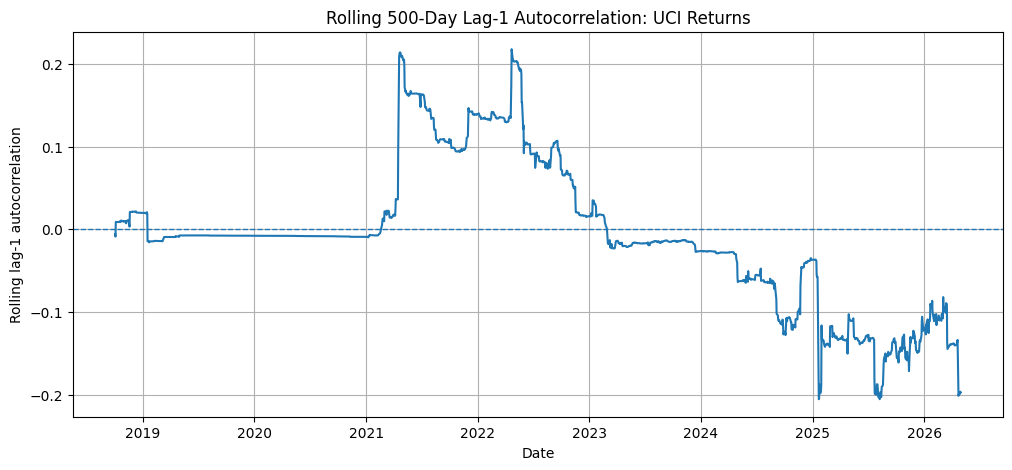

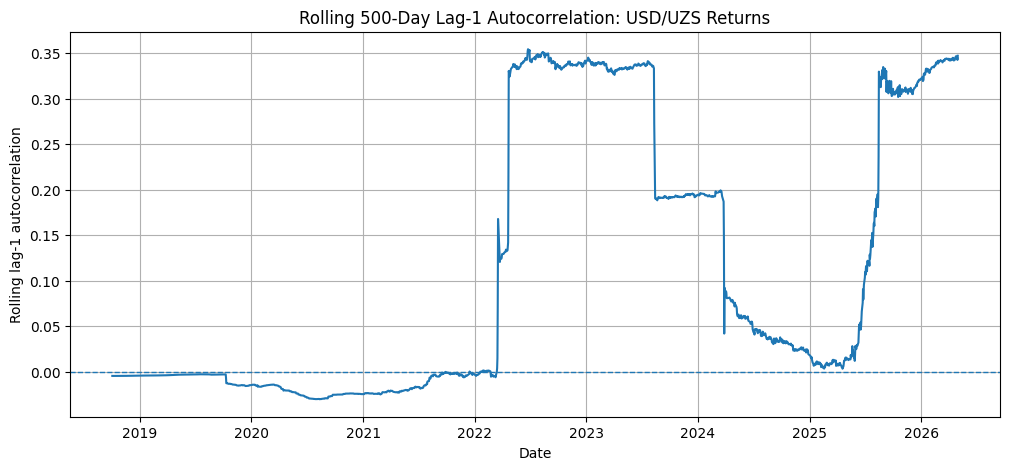

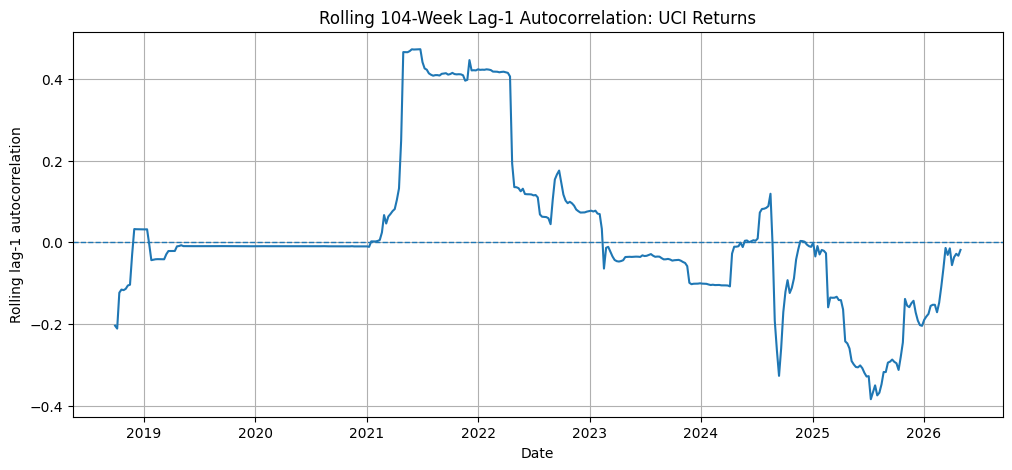

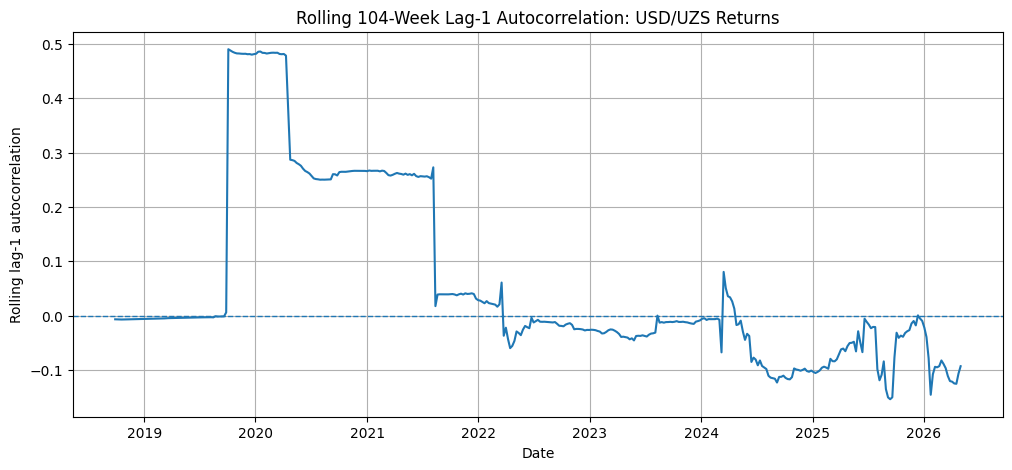

In [37]:
# ---------------------------------------------------------------------
# 31. Plot rolling autocorrelations
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt

def plot_rolling_autocorr(data, dataset_name, title):
    plot_data = data[data["dataset"] == dataset_name].copy()

    plt.figure(figsize=(12, 5))
    plt.plot(plot_data["date"], plot_data["rolling_autocorrelation"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Rolling lag-1 autocorrelation")
    plt.grid(True)
    plt.show()


plot_rolling_autocorr(
    rolling_autocorr_results,
    "daily_uci",
    "Rolling 500-Day Lag-1 Autocorrelation: UCI Returns"
)

plot_rolling_autocorr(
    rolling_autocorr_results,
    "daily_fx",
    "Rolling 500-Day Lag-1 Autocorrelation: USD/UZS Returns"
)

plot_rolling_autocorr(
    rolling_autocorr_results,
    "weekly_uci",
    "Rolling 104-Week Lag-1 Autocorrelation: UCI Returns"
)

plot_rolling_autocorr(
    rolling_autocorr_results,
    "weekly_fx",
    "Rolling 104-Week Lag-1 Autocorrelation: USD/UZS Returns"
)

In [38]:
# ---------------------------------------------------------------------
# 32. Save rolling autocorrelation results
# ---------------------------------------------------------------------

rolling_autocorr_excel_file = output_dir / "emh_rolling_autocorrelation.xlsx"
rolling_autocorr_csv_file = output_dir / "emh_rolling_autocorrelation.csv"

with pd.ExcelWriter(rolling_autocorr_excel_file, engine="openpyxl") as writer:
    rolling_autocorr_results.to_excel(writer, sheet_name="rolling_autocorr", index=False)

rolling_autocorr_results.to_csv(
    rolling_autocorr_csv_file,
    index=False,
    encoding="utf-8-sig"
)

print("Saved rolling autocorrelation files:")
print(rolling_autocorr_excel_file)
print(rolling_autocorr_csv_file)

Saved rolling autocorrelation files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_rolling_autocorrelation.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_rolling_autocorrelation.csv


In [39]:
# ---------------------------------------------------------------------
# 33. Rolling variance-ratio analysis
# ---------------------------------------------------------------------

def rolling_variance_ratio(df, return_col, window, q, dataset_name):
    """
    Rolling variance-ratio test.
    Uses the variance_ratio_test() function defined earlier.
    """
    temp = df[["date", return_col]].dropna().copy()
    temp = temp.sort_values("date").reset_index(drop=True)

    rows = []

    for i in range(window, len(temp) + 1):
        sample = temp.iloc[i-window:i]
        vr_result = variance_ratio_test(sample[return_col], q)

        rows.append({
            "date": sample["date"].iloc[-1],
            "dataset": dataset_name,
            "variable": return_col,
            "window": window,
            "q": q,
            "variance_ratio": vr_result["variance_ratio"],
            "z_robust": vr_result["z_robust"],
            "p_robust": vr_result["p_robust"],
            "reject_5pct_robust": vr_result["reject_5pct_robust"]
        })

    return pd.DataFrame(rows)


# Use q = 4 as a balanced horizon for rolling VR
rolling_vr_daily_uci = rolling_variance_ratio(
    daily_returns, "r_uci", daily_window, 4, "daily_uci"
)

rolling_vr_daily_fx = rolling_variance_ratio(
    daily_returns, "r_fx", daily_window, 4, "daily_fx"
)

rolling_vr_weekly_uci = rolling_variance_ratio(
    weekly_returns, "r_uci", weekly_window, 4, "weekly_uci"
)

rolling_vr_weekly_fx = rolling_variance_ratio(
    weekly_returns, "r_fx", weekly_window, 4, "weekly_fx"
)

rolling_vr_results = pd.concat(
    [
        rolling_vr_daily_uci,
        rolling_vr_daily_fx,
        rolling_vr_weekly_uci,
        rolling_vr_weekly_fx
    ],
    ignore_index=True
)

print("Rolling variance-ratio results:")
display(rolling_vr_results.head())
display(rolling_vr_results.tail())

print("\nRolling VR summary:")
display(
    rolling_vr_results
    .groupby(["dataset", "variable"])["variance_ratio"]
    .describe()
)

print("\nShare of rolling windows rejecting random walk at 5%:")
display(
    rolling_vr_results
    .groupby(["dataset", "variable"])["reject_5pct_robust"]
    .mean()
    .reset_index(name="share_reject_5pct")
)

Rolling variance-ratio results:


,date,dataset,variable,window,q,variance_ratio,z_robust,p_robust,reject_5pct_robust
0,2018-10-03,daily_uci,r_uci,500,4,0.994130,-0.066570,0.946924,False
1,2018-10-04,daily_uci,r_uci,500,4,0.895092,-1.278944,0.200917,False
2,2018-10-05,daily_uci,r_uci,500,4,0.915971,-0.980279,0.326948,False
3,2018-10-08,daily_uci,r_uci,500,4,0.952115,-0.558647,0.576403,False
4,2018-10-09,daily_uci,r_uci,500,4,0.993220,-0.075090,0.940143,False


,date,dataset,variable,window,q,variance_ratio,z_robust,p_robust,reject_5pct_robust
4565,2026-04-03,weekly_fx,r_fx,104,4,0.920205,-0.348916,0.727153,False
4566,2026-04-10,weekly_fx,r_fx,104,4,0.922480,-0.341208,0.732947,False
4567,2026-04-17,weekly_fx,r_fx,104,4,0.921051,-0.347847,0.727955,False
4568,2026-04-24,weekly_fx,r_fx,104,4,0.889019,-0.511142,0.609252,False
4569,2026-05-01,weekly_fx,r_fx,104,4,0.899229,-0.462558,0.643681,False



Rolling VR summary:


,,count,mean,std,min,25%,50%,75%,max
dataset,variable,,,,,,,,
daily_fx,r_fx,1888.0,1.140237,0.215533,0.256822,0.992703,1.090769,1.270230,1.653931
daily_uci,r_uci,1888.0,0.963823,0.217293,0.291016,0.806930,0.989928,1.025663,1.563569
weekly_fx,r_fx,397.0,1.087539,0.338250,0.266464,0.902867,0.982441,1.086097,2.045758
weekly_uci,r_uci,397.0,0.971121,0.347340,0.282743,0.757233,0.931060,1.100197,1.814457



Share of rolling windows rejecting random walk at 5%:


,dataset,variable,share_reject_5pct
0,daily_fx,r_fx,0.002119
1,daily_uci,r_uci,0.260593
2,weekly_fx,r_fx,0.032746
3,weekly_uci,r_uci,0.103275


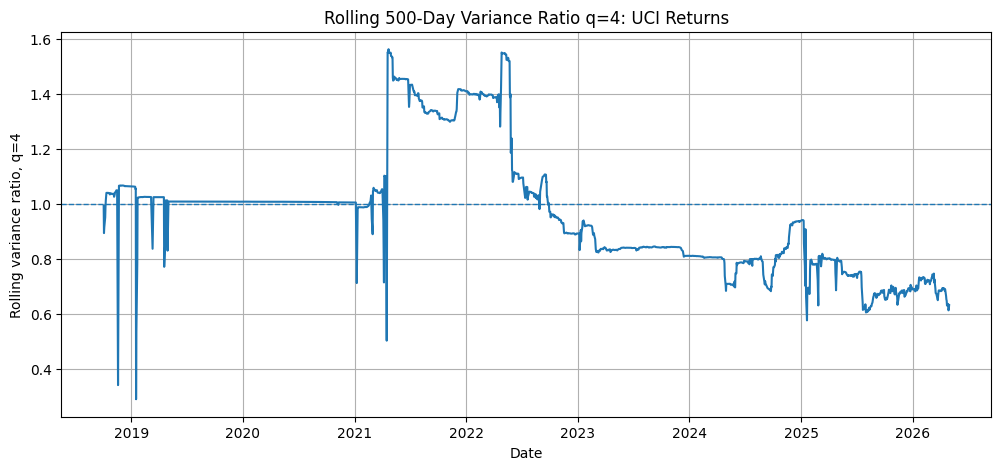

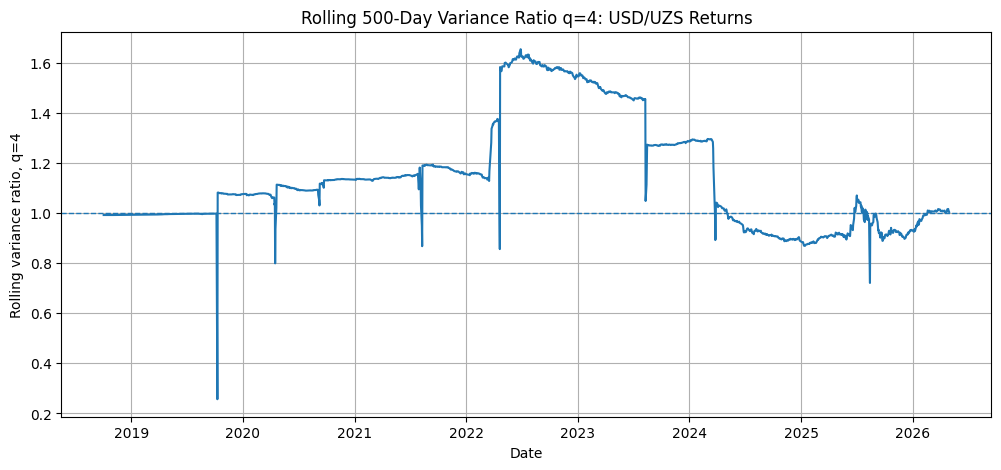

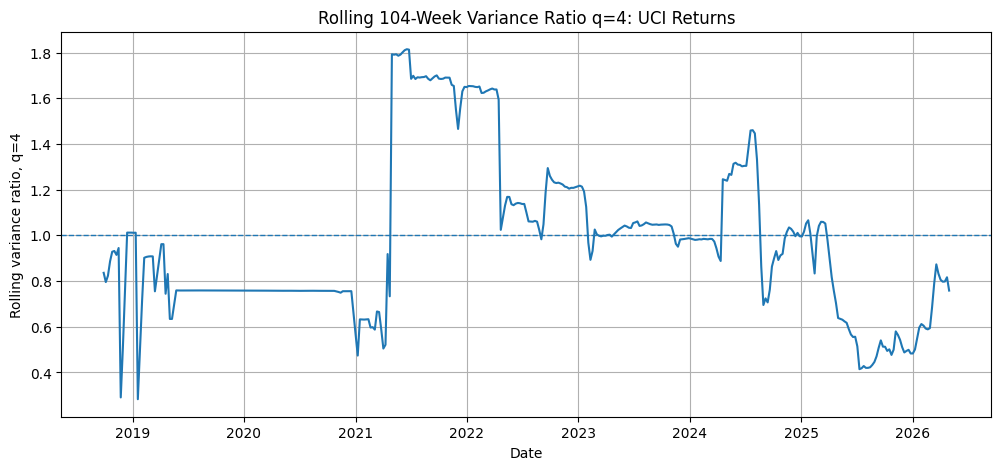

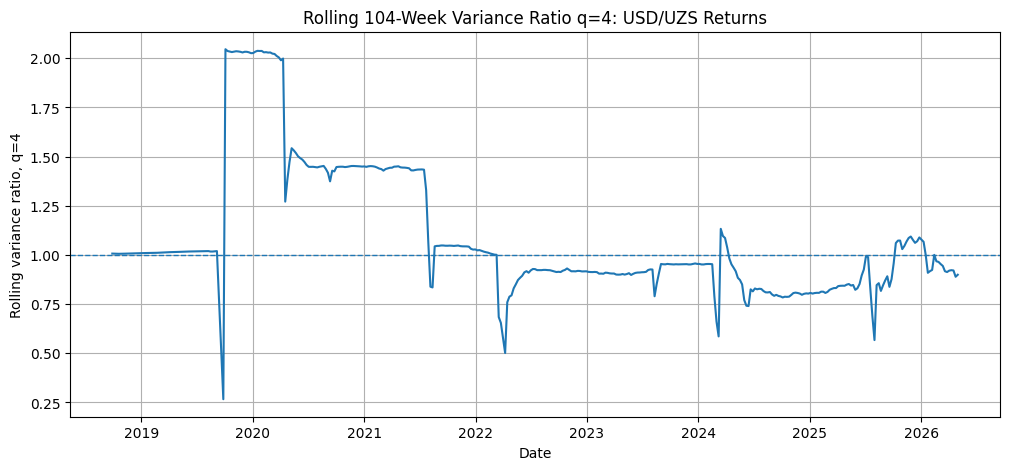

In [40]:
# ---------------------------------------------------------------------
# 34. Plot rolling variance ratios
# ---------------------------------------------------------------------

def plot_rolling_vr(data, dataset_name, title):
    plot_data = data[data["dataset"] == dataset_name].copy()

    plt.figure(figsize=(12, 5))
    plt.plot(plot_data["date"], plot_data["variance_ratio"])
    plt.axhline(1, linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Rolling variance ratio, q=4")
    plt.grid(True)
    plt.show()


plot_rolling_vr(
    rolling_vr_results,
    "daily_uci",
    "Rolling 500-Day Variance Ratio q=4: UCI Returns"
)

plot_rolling_vr(
    rolling_vr_results,
    "daily_fx",
    "Rolling 500-Day Variance Ratio q=4: USD/UZS Returns"
)

plot_rolling_vr(
    rolling_vr_results,
    "weekly_uci",
    "Rolling 104-Week Variance Ratio q=4: UCI Returns"
)

plot_rolling_vr(
    rolling_vr_results,
    "weekly_fx",
    "Rolling 104-Week Variance Ratio q=4: USD/UZS Returns"
)

In [41]:
# ---------------------------------------------------------------------
# 35. Save rolling variance-ratio results
# ---------------------------------------------------------------------

rolling_vr_excel_file = output_dir / "emh_rolling_variance_ratio.xlsx"
rolling_vr_csv_file = output_dir / "emh_rolling_variance_ratio.csv"

with pd.ExcelWriter(rolling_vr_excel_file, engine="openpyxl") as writer:
    rolling_vr_results.to_excel(writer, sheet_name="rolling_vr", index=False)

rolling_vr_results.to_csv(
    rolling_vr_csv_file,
    index=False,
    encoding="utf-8-sig"
)

print("Saved rolling variance-ratio files:")
print(rolling_vr_excel_file)
print(rolling_vr_csv_file)

Saved rolling variance-ratio files:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_rolling_variance_ratio.xlsx
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_rolling_variance_ratio.csv


In [42]:
# ---------------------------------------------------------------------
# 36. Create final summary table of main test conclusions
# ---------------------------------------------------------------------

final_summary = pd.DataFrame({
    "Test group": [
        "Autocorrelation / Ljung-Box",
        "Runs test",
        "Variance-ratio full sample",
        "ADF / PP with trend",
        "FX reform split",
        "Rolling autocorrelation",
        "Rolling variance-ratio"
    ],
    "UCI result": [
        "Some evidence of serial dependence, especially Ljung-Box at selected horizons",
        "Daily rejects randomness; weekly does not reject",
        "Does not reject random walk at daily or weekly frequency",
        "Mixed evidence after including trend",
        "Not primary reform market; use rolling analysis",
        "Autocorrelation changes over time; positive and negative episodes",
        "Mostly close to random walk, but daily windows reject in about 26% of cases"
    ],
    "USD/UZS result": [
        "Full sample mostly weak linear dependence, but reform/no-jump tests show dependence",
        "Rejects randomness in full sample; sign clustering exists",
        "Mixed evidence; selected horizons reject",
        "With trend, does not reject unit root",
        "Clear regime change after 2017; partial improvement but not full efficiency",
        "Strong time variation across regimes",
        "Mostly does not reject random walk; small share of rejecting windows"
    ],
    "Interpretation": [
        "Evidence is mixed; dependence is not uniform across markets/frequencies",
        "Daily sign behavior is non-random, but UCI weekly results support microstructure explanation",
        "Main random-walk test supports UCI more strongly than FX",
        "Supportive only; not the main EMH conclusion",
        "2017 reform is a structural break / regime shift",
        "Supports adaptive/time-varying efficiency",
        "Supports partial and time-varying efficiency rather than full inefficiency"
    ]
})

display(final_summary)

summary_file = output_dir / "emh_final_results_summary.xlsx"

with pd.ExcelWriter(summary_file, engine="openpyxl") as writer:
    final_summary.to_excel(writer, sheet_name="final_summary", index=False)

print("Saved final summary table:")
print(summary_file)

,Test group,UCI result,USD/UZS result,Interpretation
0,Autocorrelation / Ljung-Box,"Some evidence of serial dependence, especially...","Full sample mostly weak linear dependence, but...",Evidence is mixed; dependence is not uniform a...
1,Runs test,Daily rejects randomness; weekly does not reject,Rejects randomness in full sample; sign cluste...,"Daily sign behavior is non-random, but UCI wee..."
2,Variance-ratio full sample,Does not reject random walk at daily or weekly...,Mixed evidence; selected horizons reject,Main random-walk test supports UCI more strong...
3,ADF / PP with trend,Mixed evidence after including trend,"With trend, does not reject unit root",Supportive only; not the main EMH conclusion
4,FX reform split,Not primary reform market; use rolling analysis,Clear regime change after 2017; partial improv...,2017 reform is a structural break / regime shift
5,Rolling autocorrelation,Autocorrelation changes over time; positive an...,Strong time variation across regimes,Supports adaptive/time-varying efficiency
6,Rolling variance-ratio,"Mostly close to random walk, but daily windows...",Mostly does not reject random walk; small shar...,Supports partial and time-varying efficiency r...


Saved final summary table:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\emh_final_results_summary.xlsx


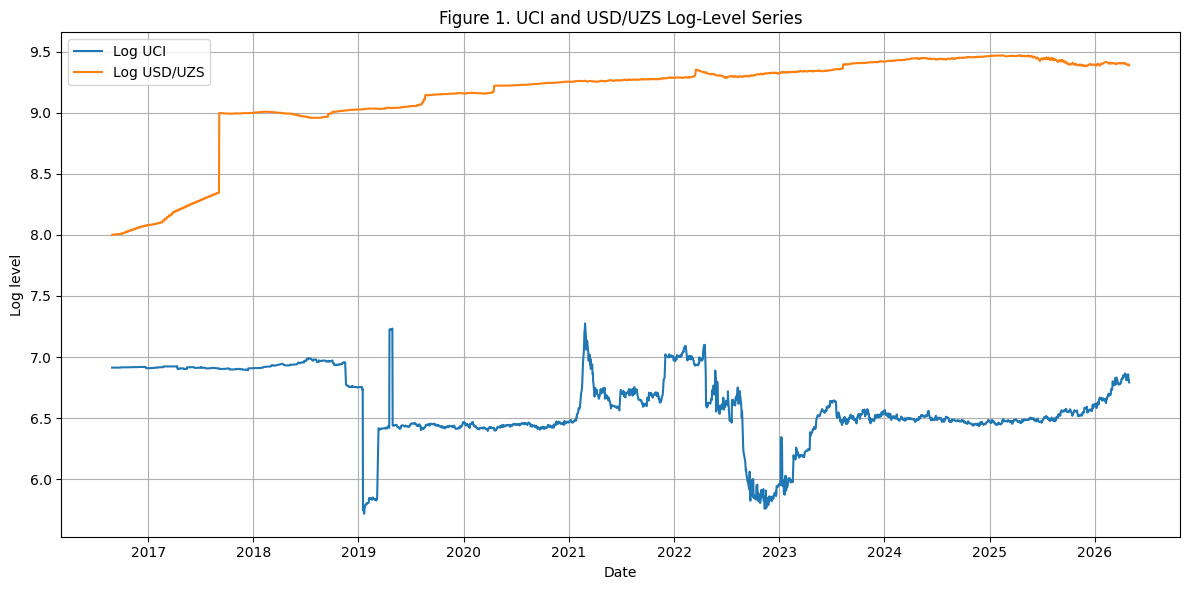

Saved Figure 1:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_1_uci_usduzs_log_levels.png


In [43]:
# ---------------------------------------------------------------------
# Figure 1. UCI and USD/UZS log-level series
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# Make sure date is datetime
daily["date"] = pd.to_datetime(daily["date"])

# Make sure log variables exist
if "log_uci" not in daily.columns:
    daily["log_uci"] = np.log(daily["uci"])

if "log_fx" not in daily.columns:
    daily["log_fx"] = np.log(daily["usd_uzs"])

# Plot
plt.figure(figsize=(12, 6))

plt.plot(daily["date"], daily["log_uci"], label="Log UCI")
plt.plot(daily["date"], daily["log_fx"], label="Log USD/UZS")

plt.title("Figure 1. UCI and USD/UZS Log-Level Series")
plt.xlabel("Date")
plt.ylabel("Log level")
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save figure
figure1_file = output_dir / "figure_1_uci_usduzs_log_levels.png"
plt.savefig(figure1_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 1:")
print(figure1_file)

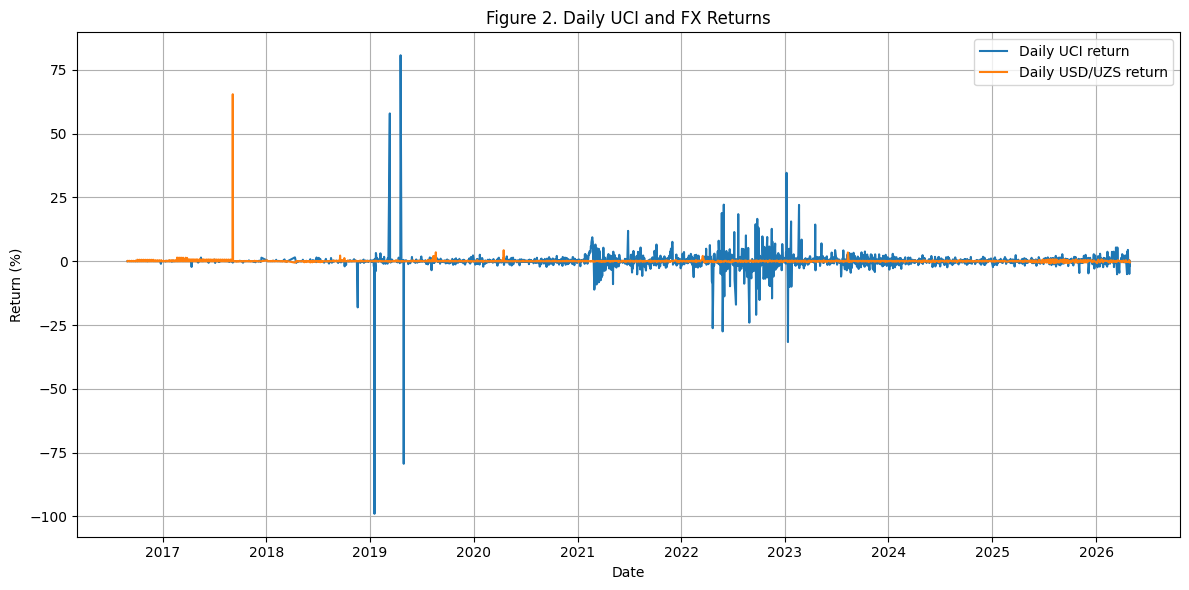

Saved Figure 2:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_2_daily_uci_fx_returns.png


In [44]:
# ---------------------------------------------------------------------
# Figure 2. Daily UCI and FX returns
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Make sure date is datetime
daily["date"] = pd.to_datetime(daily["date"])

# Make sure return variables exist
# If they already exist, these lines do nothing
if "r_uci" not in daily.columns:
    daily["r_uci"] = 100 * (np.log(daily["uci"]) - np.log(daily["uci"]).shift(1))

if "r_fx" not in daily.columns:
    daily["r_fx"] = 100 * (np.log(daily["usd_uzs"]) - np.log(daily["usd_uzs"]).shift(1))

# Plot both daily return series
plt.figure(figsize=(12, 6))

plt.plot(daily["date"], daily["r_uci"], label="Daily UCI return")
plt.plot(daily["date"], daily["r_fx"], label="Daily USD/UZS return")

plt.title("Figure 2. Daily UCI and FX Returns")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
figure2_file = output_dir / "figure_2_daily_uci_fx_returns.png"
plt.savefig(figure2_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 2:")
print(figure2_file)

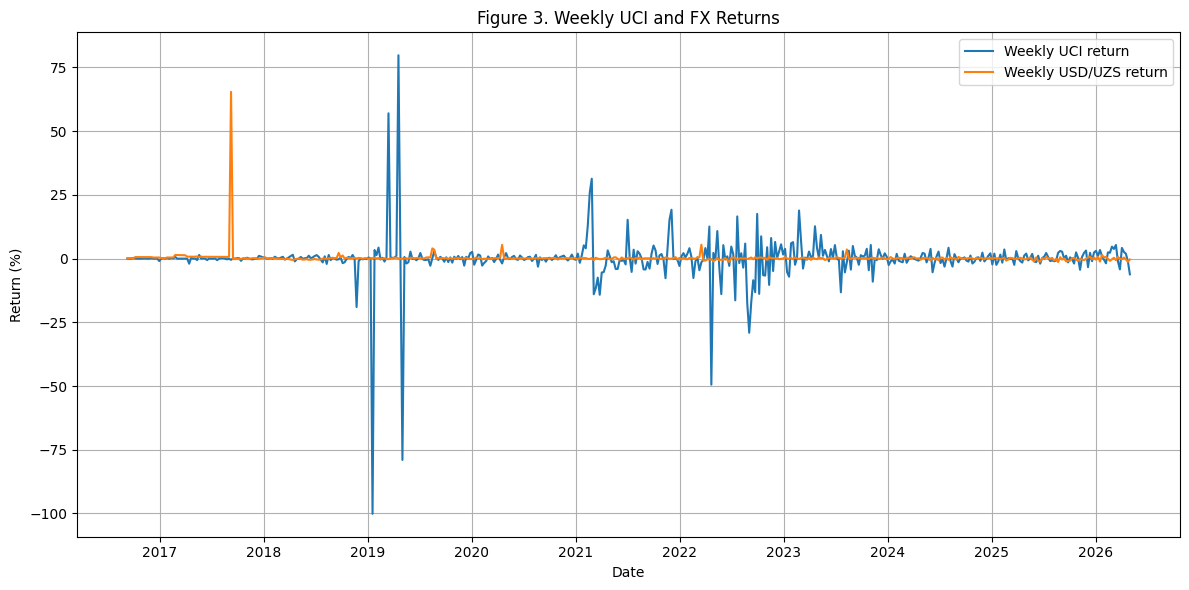

Saved Figure 3:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_3_weekly_uci_fx_returns.png


In [45]:
# ---------------------------------------------------------------------
# Figure 3. Weekly UCI and FX returns
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Make sure date is datetime
weekly_returns["date"] = pd.to_datetime(weekly_returns["date"])

# Make sure return variables exist
# If they already exist, these lines do nothing
if "r_uci" not in weekly_returns.columns:
    weekly_returns["r_uci"] = 100 * (
        np.log(weekly_returns["uci"]) - np.log(weekly_returns["uci"]).shift(1)
    )

if "r_fx" not in weekly_returns.columns:
    weekly_returns["r_fx"] = 100 * (
        np.log(weekly_returns["usd_uzs"]) - np.log(weekly_returns["usd_uzs"]).shift(1)
    )

# Plot both weekly return series
plt.figure(figsize=(12, 6))

plt.plot(weekly_returns["date"], weekly_returns["r_uci"], label="Weekly UCI return")
plt.plot(weekly_returns["date"], weekly_returns["r_fx"], label="Weekly USD/UZS return")

plt.title("Figure 3. Weekly UCI and FX Returns")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
figure3_file = output_dir / "figure_3_weekly_uci_fx_returns.png"
plt.savefig(figure3_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 3:")
print(figure3_file)

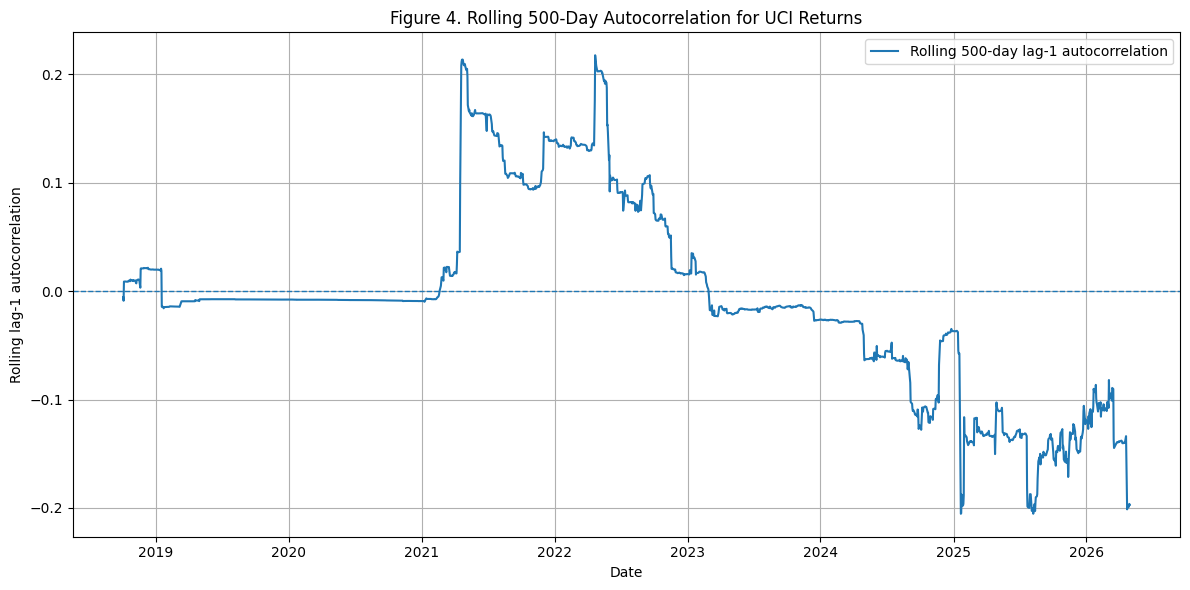

Saved Figure 4:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_4_rolling_500day_autocorrelation_uci.png


In [47]:
# ---------------------------------------------------------------------
# Figure 4. Rolling 500-day autocorrelation for UCI returns
# ---------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure date is datetime
daily_returns["date"] = pd.to_datetime(daily_returns["date"])

# Function for rolling autocorrelation
def rolling_autocorrelation(df, return_col, window=500, lag=1):
    temp = df[["date", return_col]].dropna().copy()
    temp = temp.sort_values("date").reset_index(drop=True)

    rows = []

    for i in range(window, len(temp) + 1):
        sample = temp.iloc[i-window:i]
        rho = sample[return_col].autocorr(lag=lag)

        rows.append({
            "date": sample["date"].iloc[-1],
            "rolling_autocorrelation": rho
        })

    return pd.DataFrame(rows)

# Calculate rolling 500-day lag-1 autocorrelation for UCI
rolling_uci_500 = rolling_autocorrelation(
    daily_returns,
    return_col="r_uci",
    window=500,
    lag=1
)

# Plot Figure 4
plt.figure(figsize=(12, 6))

plt.plot(
    rolling_uci_500["date"],
    rolling_uci_500["rolling_autocorrelation"],
    label="Rolling 500-day lag-1 autocorrelation"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Figure 4. Rolling 500-Day Autocorrelation for UCI Returns")
plt.xlabel("Date")
plt.ylabel("Rolling lag-1 autocorrelation")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
figure4_file = output_dir / "figure_4_rolling_500day_autocorrelation_uci.png"
plt.savefig(figure4_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 4:")
print(figure4_file)

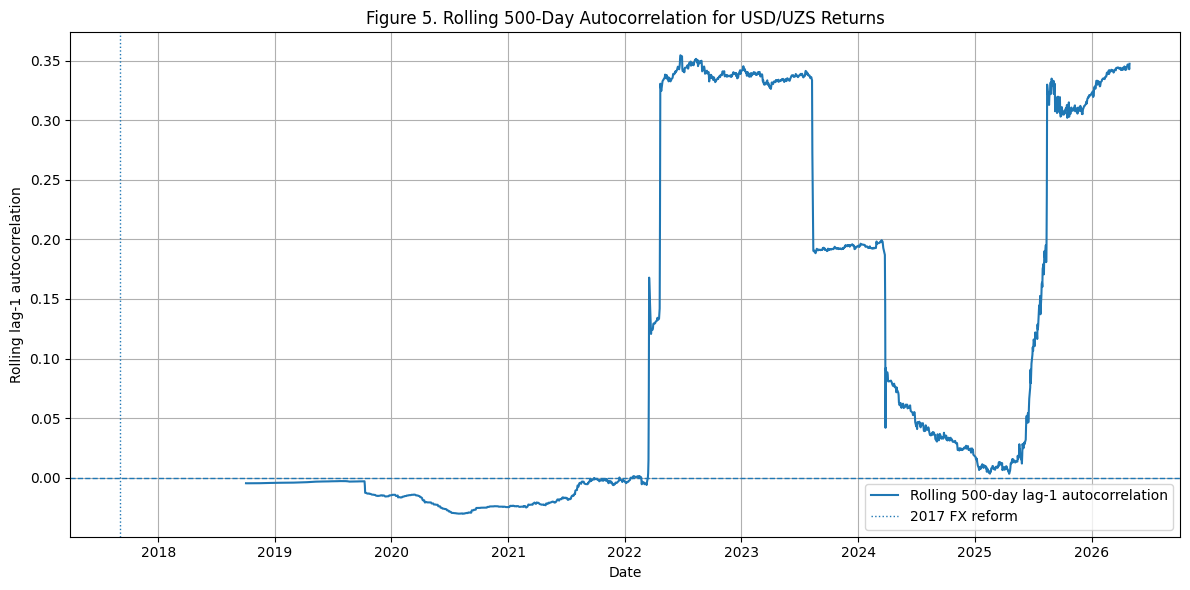

Saved Figure 5:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_5_rolling_500day_autocorrelation_fx.png


In [48]:
# ---------------------------------------------------------------------
# Figure 5. Rolling 500-day autocorrelation for USD/UZS returns
# ---------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure date is datetime
daily_returns["date"] = pd.to_datetime(daily_returns["date"])

# Function for rolling autocorrelation
def rolling_autocorrelation(df, return_col, window=500, lag=1):
    temp = df[["date", return_col]].dropna().copy()
    temp = temp.sort_values("date").reset_index(drop=True)

    rows = []

    for i in range(window, len(temp) + 1):
        sample = temp.iloc[i-window:i]
        rho = sample[return_col].autocorr(lag=lag)

        rows.append({
            "date": sample["date"].iloc[-1],
            "rolling_autocorrelation": rho
        })

    return pd.DataFrame(rows)

# Calculate rolling 500-day lag-1 autocorrelation for FX
rolling_fx_500 = rolling_autocorrelation(
    daily_returns,
    return_col="r_fx",
    window=500,
    lag=1
)

# Plot Figure 5
plt.figure(figsize=(12, 6))

plt.plot(
    rolling_fx_500["date"],
    rolling_fx_500["rolling_autocorrelation"],
    label="Rolling 500-day lag-1 autocorrelation"
)

plt.axhline(0, linestyle="--", linewidth=1)

# Optional: mark 2017 FX reform date
plt.axvline(
    pd.Timestamp("2017-09-05"),
    linestyle=":",
    linewidth=1,
    label="2017 FX reform"
)

plt.title("Figure 5. Rolling 500-Day Autocorrelation for USD/UZS Returns")
plt.xlabel("Date")
plt.ylabel("Rolling lag-1 autocorrelation")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
figure5_file = output_dir / "figure_5_rolling_500day_autocorrelation_fx.png"
plt.savefig(figure5_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 5:")
print(figure5_file)

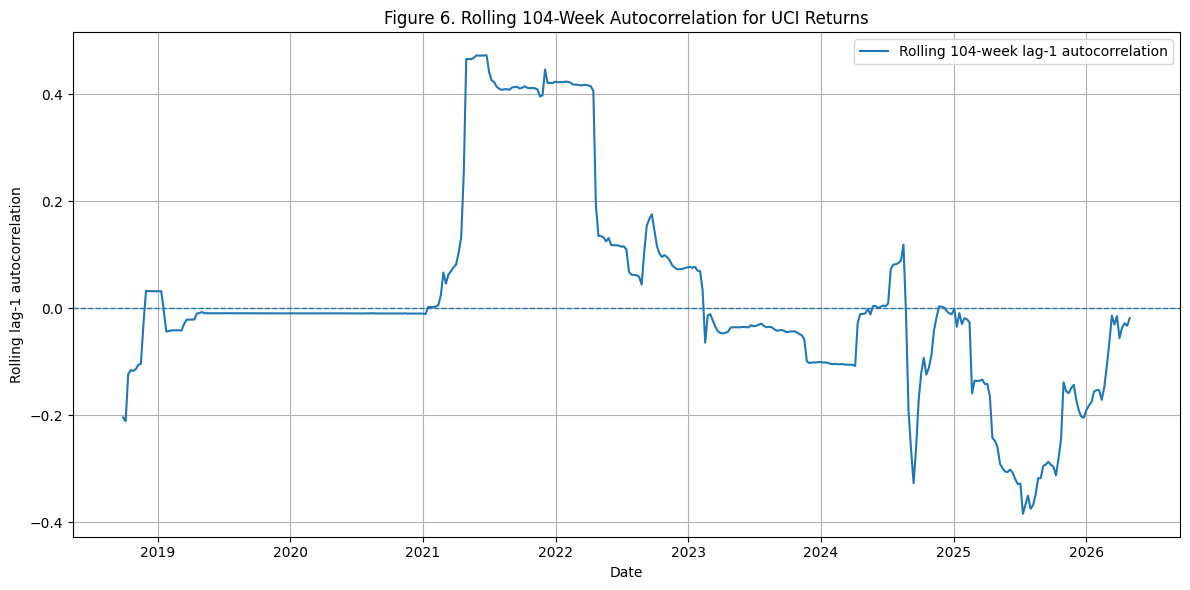

Saved Figure 6:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_6_rolling_104week_autocorrelation_uci.png


In [49]:
# ---------------------------------------------------------------------
# Figure 6. Rolling 104-week autocorrelation for UCI returns
# ---------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure date is datetime
weekly_returns["date"] = pd.to_datetime(weekly_returns["date"])

# Function for rolling autocorrelation
def rolling_autocorrelation(df, return_col, window=104, lag=1):
    temp = df[["date", return_col]].dropna().copy()
    temp = temp.sort_values("date").reset_index(drop=True)

    rows = []

    for i in range(window, len(temp) + 1):
        sample = temp.iloc[i-window:i]
        rho = sample[return_col].autocorr(lag=lag)

        rows.append({
            "date": sample["date"].iloc[-1],
            "rolling_autocorrelation": rho
        })

    return pd.DataFrame(rows)

# Calculate rolling 104-week lag-1 autocorrelation for UCI
rolling_uci_104w = rolling_autocorrelation(
    weekly_returns,
    return_col="r_uci",
    window=104,
    lag=1
)

# Plot Figure 6
plt.figure(figsize=(12, 6))

plt.plot(
    rolling_uci_104w["date"],
    rolling_uci_104w["rolling_autocorrelation"],
    label="Rolling 104-week lag-1 autocorrelation"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Figure 6. Rolling 104-Week Autocorrelation for UCI Returns")
plt.xlabel("Date")
plt.ylabel("Rolling lag-1 autocorrelation")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
figure6_file = output_dir / "figure_6_rolling_104week_autocorrelation_uci.png"
plt.savefig(figure6_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 6:")
print(figure6_file)

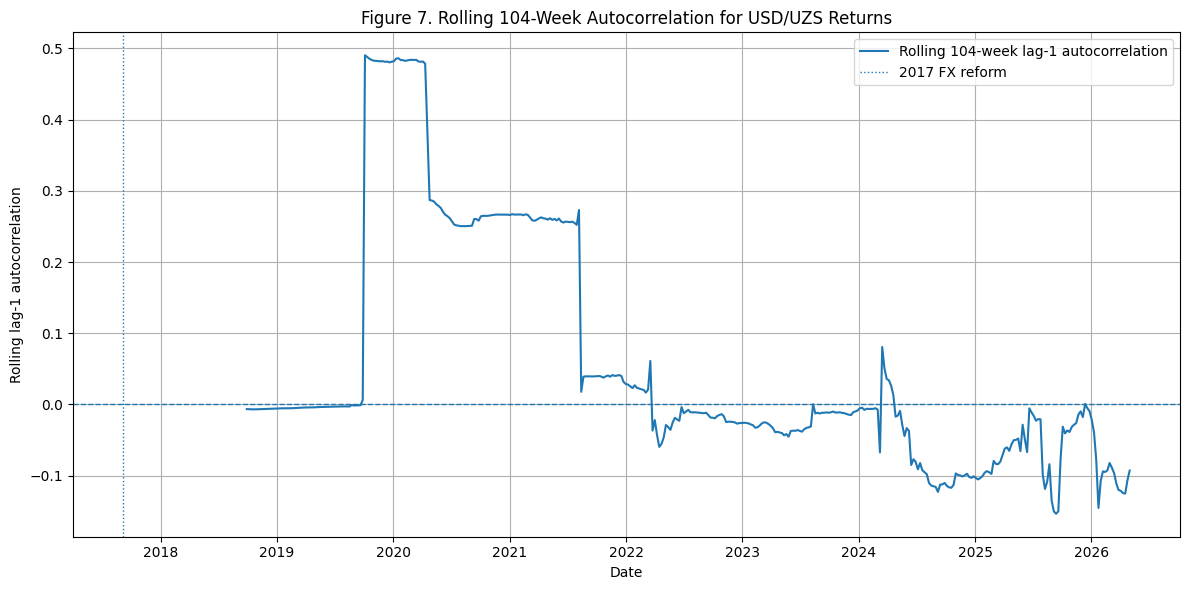

Saved Figure 7:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_7_rolling_104week_autocorrelation_fx.png


In [50]:
# ---------------------------------------------------------------------
# Figure 7. Rolling 104-week autocorrelation for USD/UZS returns
# ---------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure date is datetime
weekly_returns["date"] = pd.to_datetime(weekly_returns["date"])

# Function for rolling autocorrelation
def rolling_autocorrelation(df, return_col, window=104, lag=1):
    temp = df[["date", return_col]].dropna().copy()
    temp = temp.sort_values("date").reset_index(drop=True)

    rows = []

    for i in range(window, len(temp) + 1):
        sample = temp.iloc[i-window:i]
        rho = sample[return_col].autocorr(lag=lag)

        rows.append({
            "date": sample["date"].iloc[-1],
            "rolling_autocorrelation": rho
        })

    return pd.DataFrame(rows)

# Calculate rolling 104-week lag-1 autocorrelation for FX
rolling_fx_104w = rolling_autocorrelation(
    weekly_returns,
    return_col="r_fx",
    window=104,
    lag=1
)

# Plot Figure 7
plt.figure(figsize=(12, 6))

plt.plot(
    rolling_fx_104w["date"],
    rolling_fx_104w["rolling_autocorrelation"],
    label="Rolling 104-week lag-1 autocorrelation"
)

plt.axhline(0, linestyle="--", linewidth=1)

# Optional: mark 2017 FX reform
plt.axvline(
    pd.Timestamp("2017-09-05"),
    linestyle=":",
    linewidth=1,
    label="2017 FX reform"
)

plt.title("Figure 7. Rolling 104-Week Autocorrelation for USD/UZS Returns")
plt.xlabel("Date")
plt.ylabel("Rolling lag-1 autocorrelation")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
figure7_file = output_dir / "figure_7_rolling_104week_autocorrelation_fx.png"
plt.savefig(figure7_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 7:")
print(figure7_file)

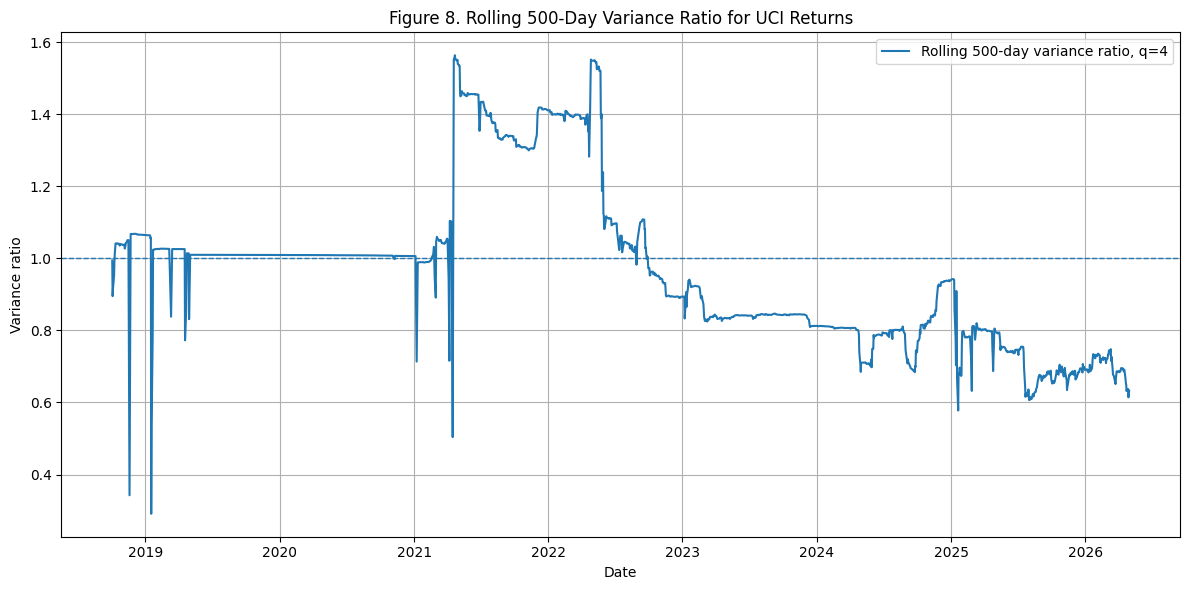

Saved Figure 8:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_8_rolling_500day_variance_ratio_uci.png


In [51]:
# ---------------------------------------------------------------------
# Figure 8. Rolling 500-day variance ratio for UCI returns
# ---------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

daily_returns["date"] = pd.to_datetime(daily_returns["date"])

# Define variance-ratio function if not already defined
def variance_ratio_test(series, q):
    x = series.dropna().astype(float).values
    n = len(x)

    if n <= q + 1:
        return {"variance_ratio": np.nan, "p_robust": np.nan, "reject_5pct_robust": np.nan}

    mu = np.mean(x)
    x_centered = x - mu
    var_1 = np.var(x_centered, ddof=1)

    q_returns = np.array([
        np.sum(x[i-q+1:i+1]) for i in range(q-1, n)
    ])

    var_q = np.var(q_returns, ddof=1)
    vr = var_q / (q * var_1)

    denom = np.sum(x_centered ** 2) ** 2
    theta_sum = 0

    for j in range(1, q):
        delta_j = np.sum(
            (x_centered[j:] ** 2) * (x_centered[:-j] ** 2)
        ) / denom

        weight = (2 * (q - j) / q) ** 2
        theta_sum += weight * delta_j

    if theta_sum > 0:
        z_robust = (vr - 1) / np.sqrt(theta_sum)
        p_robust = 2 * (1 - stats.norm.cdf(abs(z_robust)))
    else:
        p_robust = np.nan

    return {
        "variance_ratio": vr,
        "p_robust": p_robust,
        "reject_5pct_robust": p_robust < 0.05 if not np.isnan(p_robust) else np.nan
    }


def rolling_variance_ratio(df, return_col, window=500, q=4):
    temp = df[["date", return_col]].dropna().copy()
    temp = temp.sort_values("date").reset_index(drop=True)

    rows = []

    for i in range(window, len(temp) + 1):
        sample = temp.iloc[i-window:i]
        result = variance_ratio_test(sample[return_col], q)

        rows.append({
            "date": sample["date"].iloc[-1],
            "variance_ratio": result["variance_ratio"],
            "p_robust": result["p_robust"],
            "reject_5pct_robust": result["reject_5pct_robust"]
        })

    return pd.DataFrame(rows)


rolling_vr_uci_500 = rolling_variance_ratio(
    daily_returns,
    return_col="r_uci",
    window=500,
    q=4
)

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_vr_uci_500["date"],
    rolling_vr_uci_500["variance_ratio"],
    label="Rolling 500-day variance ratio, q=4"
)

plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Figure 8. Rolling 500-Day Variance Ratio for UCI Returns")
plt.xlabel("Date")
plt.ylabel("Variance ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

figure8_file = output_dir / "figure_8_rolling_500day_variance_ratio_uci.png"
plt.savefig(figure8_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 8:")
print(figure8_file)

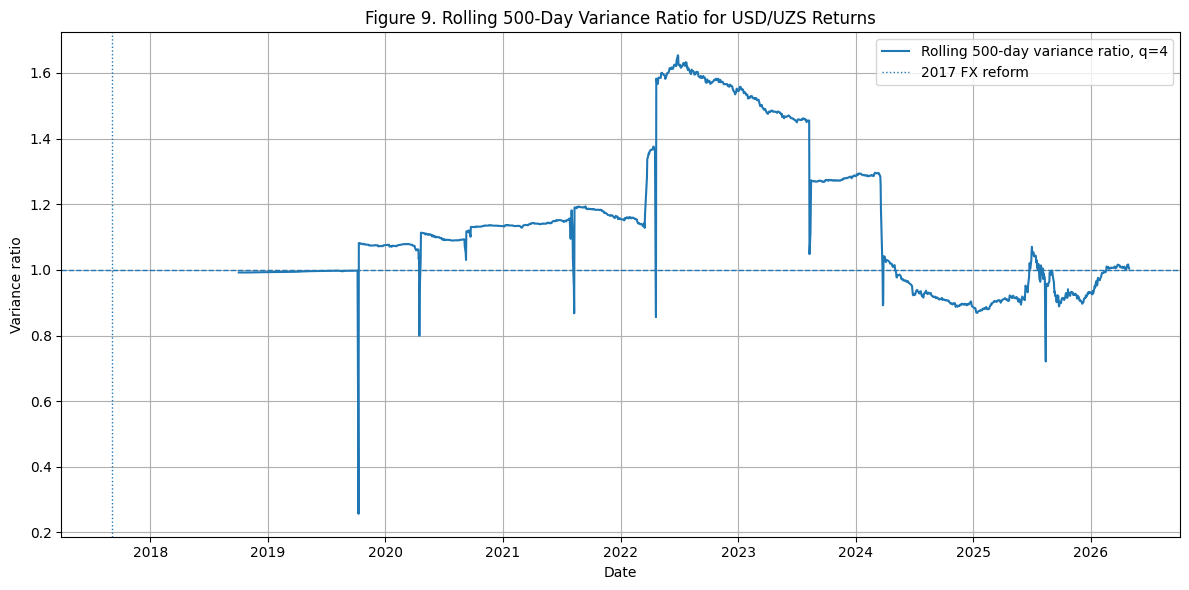

Saved Figure 9:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_9_rolling_500day_variance_ratio_fx.png


In [52]:
# ---------------------------------------------------------------------
# Figure 9. Rolling 500-day variance ratio for USD/UZS returns
# ---------------------------------------------------------------------

daily_returns["date"] = pd.to_datetime(daily_returns["date"])

rolling_vr_fx_500 = rolling_variance_ratio(
    daily_returns,
    return_col="r_fx",
    window=500,
    q=4
)

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_vr_fx_500["date"],
    rolling_vr_fx_500["variance_ratio"],
    label="Rolling 500-day variance ratio, q=4"
)

plt.axhline(1, linestyle="--", linewidth=1)

# Mark 2017 FX reform
plt.axvline(
    pd.Timestamp("2017-09-05"),
    linestyle=":",
    linewidth=1,
    label="2017 FX reform"
)

plt.title("Figure 9. Rolling 500-Day Variance Ratio for USD/UZS Returns")
plt.xlabel("Date")
plt.ylabel("Variance ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

figure9_file = output_dir / "figure_9_rolling_500day_variance_ratio_fx.png"
plt.savefig(figure9_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 9:")
print(figure9_file)

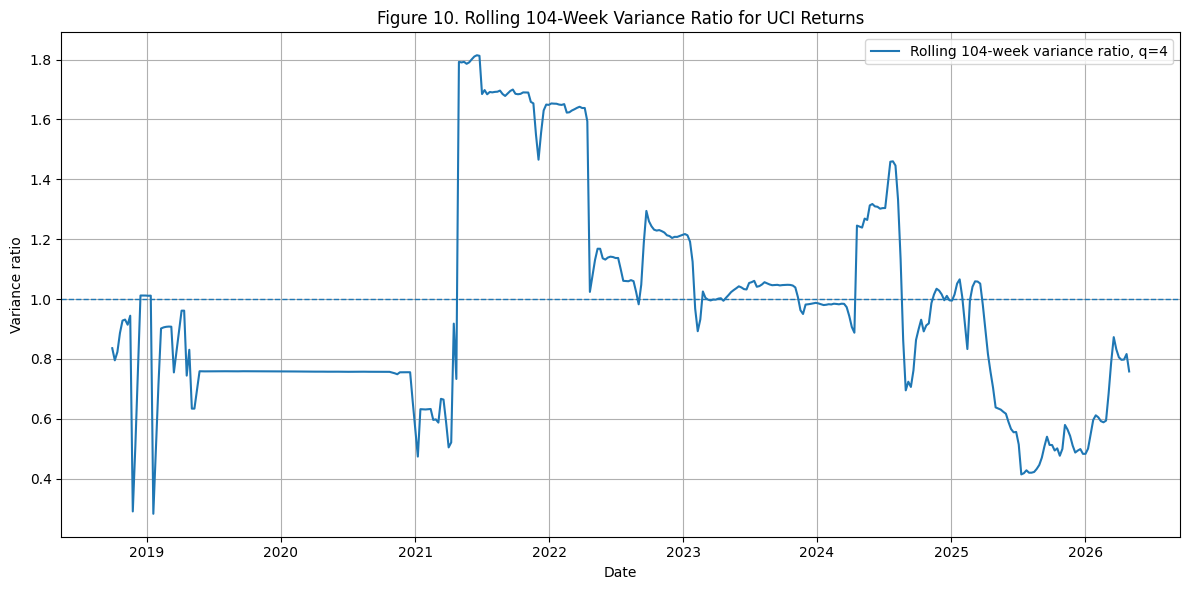

Saved Figure 10:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_10_rolling_104week_variance_ratio_uci.png


In [53]:
# ---------------------------------------------------------------------
# Figure 10. Rolling 104-week variance ratio for UCI returns
# ---------------------------------------------------------------------

weekly_returns["date"] = pd.to_datetime(weekly_returns["date"])

rolling_vr_uci_104w = rolling_variance_ratio(
    weekly_returns,
    return_col="r_uci",
    window=104,
    q=4
)

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_vr_uci_104w["date"],
    rolling_vr_uci_104w["variance_ratio"],
    label="Rolling 104-week variance ratio, q=4"
)

plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Figure 10. Rolling 104-Week Variance Ratio for UCI Returns")
plt.xlabel("Date")
plt.ylabel("Variance ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

figure10_file = output_dir / "figure_10_rolling_104week_variance_ratio_uci.png"
plt.savefig(figure10_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 10:")
print(figure10_file)

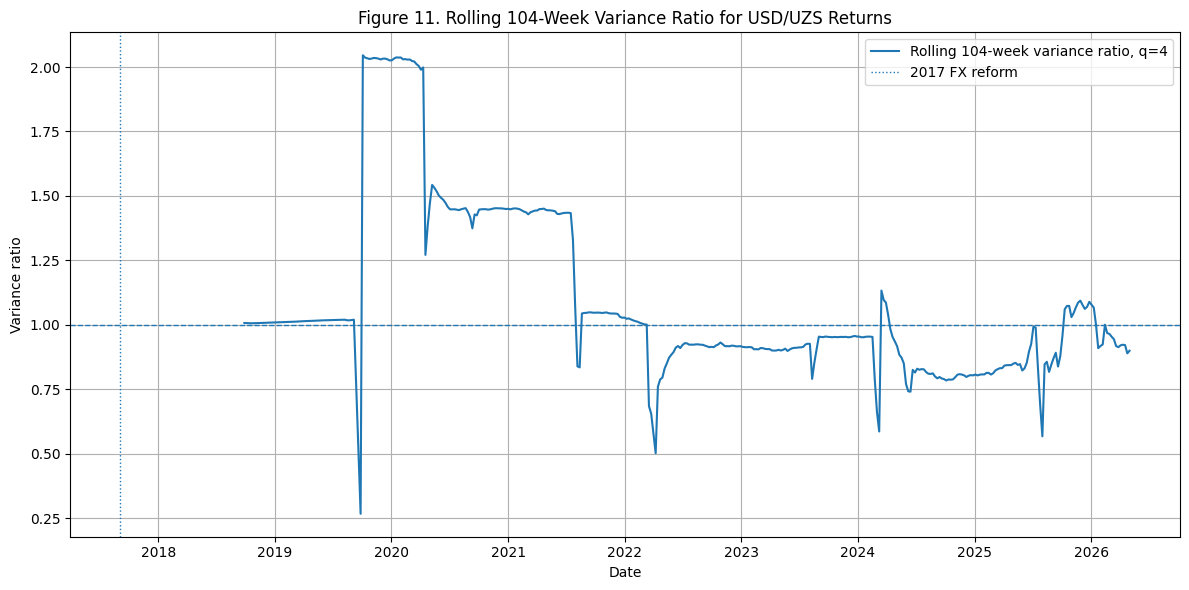

Saved Figure 11:
D:\emh to prof. m.djurayeva\datasets\cleaned_outputs\figure_11_rolling_104week_variance_ratio_fx.png


In [54]:
# ---------------------------------------------------------------------
# Figure 11. Rolling 104-week variance ratio for USD/UZS returns
# ---------------------------------------------------------------------

weekly_returns["date"] = pd.to_datetime(weekly_returns["date"])

rolling_vr_fx_104w = rolling_variance_ratio(
    weekly_returns,
    return_col="r_fx",
    window=104,
    q=4
)

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_vr_fx_104w["date"],
    rolling_vr_fx_104w["variance_ratio"],
    label="Rolling 104-week variance ratio, q=4"
)

plt.axhline(1, linestyle="--", linewidth=1)

# Mark 2017 FX reform
plt.axvline(
    pd.Timestamp("2017-09-05"),
    linestyle=":",
    linewidth=1,
    label="2017 FX reform"
)

plt.title("Figure 11. Rolling 104-Week Variance Ratio for USD/UZS Returns")
plt.xlabel("Date")
plt.ylabel("Variance ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

figure11_file = output_dir / "figure_11_rolling_104week_variance_ratio_fx.png"
plt.savefig(figure11_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved Figure 11:")
print(figure11_file)